Results plots

In [24]:
using ImageFiltering

function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end

using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=1.0
)

    sigma_90 = quantile(Chisq(2), 0.90)  # Fixed: use sigma_90 consistently

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        # works for both load(fp)["result"]
        # and only(values(load(fp)))
        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))  # PRD single column: 8.6 cm width (unchanged)

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        #title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = false,
        yminorgridvisible = false,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18
    )
    colsize!(fig.layout, 1, Relative(0.95))  # Axis takes 95% of width

    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        # --- COLOR FIX ---
        linecolor = if label == "Combined Data" || label == "Combined Projection"
            :black
        else
            colors[i]  # Fixed: was colors[idx] but idx not defined
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,  # Fixed: use linecolor instead of colors[i] for consistency
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (i,label) in enumerate(experiments)

            force_dashed =
                label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Projection"]

            push!(
                legend_elements,
                LineElement(
                    color=colors[i],
                    linewidth=2.5,
                    linestyle=force_dashed ? :dot : :solid
                )
            )

            push!(legend_labels, label)
        end

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=2.5,
            linestyle=:solid,
           # points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Data")

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=2.5,
            linestyle=:dot,
          #  points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Projection")

        
        # style explanation
      
        #keep_labels = Set(["Daya Bay","JUNOTAO","KATRIN","GERDA","LEGEND200","LEGEND1000", "Combined Data", "Combined Projection"])

        #filtered_indices = [i for (i, label) in enumerate(experiments) if label in keep_labels]
        
        keep=[1,2,3,4,5,6,9,10]
        Legend(
            fig[1,1],
            legend_elements[keep],
            legend_labels[keep];
            tellwidth=false,
            tellheight=false,
            halign=:right,
            valign=:bottom,
            labelsize=18
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

In [176]:
# Modified superpose_contours function with organized legend
function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=1.0
)

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    if experiments !== nothing
        # Force Daya Bay to use the 8th color from the colorscheme
        idx_dayabay = findfirst(==("Daya Bay"), experiments)
        if idx_dayabay !== nothing
            colors[idx_dayabay] = cs.colors[8]  # Get directly from colorscheme
        end
    end    

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = false,
        yminorgridvisible = false,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18
    )
    colsize!(fig.layout, 1, Relative(0.95))

    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed = i in [2,5,6,8]  # Index-based approach for projections
        # Projections: JUNO+TAO (2), LEGEND200 (5), LEGEND1000 (6), Combined Projection (8)

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        linecolor = if label == "Combined Data" || label == "Combined Data + Projections"
            :black
        else
            colors[i]
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    hlines!(ax, [4999.0], color=cs.colors[1]  , linewidth=6.0)
    text!(
        ax, 
        ax.finallimits[].widths[1],  # right edge of x-axis
       4800.0,
        text="Benchmark",
        align=(:right, :top),
        offset=(-5, 0),
        fontsize=16,
        color=cs.colors[1]
    )

    

    if experiments !== nothing
        # Create organized legend
        legend_elements = []
        legend_labels = []
        
        # Current Data section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Current Data:")
        
        push!(legend_elements, LineElement(color=colors[8], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Daya Bay")
        
        push!(legend_elements, LineElement(color=colors[3], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "KATRIN")
        
        push!(legend_elements, LineElement(color=colors[4], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "GERDA")
        
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Combined")
        
        # Projections section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Projections:")
        
        push!(legend_elements, LineElement(color=colors[2], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "JUNO+TAO")
        
        push!(legend_elements, LineElement(color=colors[5], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "LEGEND200")
        
        push!(legend_elements, LineElement(color=colors[6], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "LEGEND1000")
        
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "Combined Data + Projections")
        
        # Add legend
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            backgroundcolor=(:white, 0.5),
            tellwidth=false,
            tellheight=false,
            halign=:right,
            valign=:bottom,
            labelsize=18,
            margin=(10, 10, 20, 10)
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

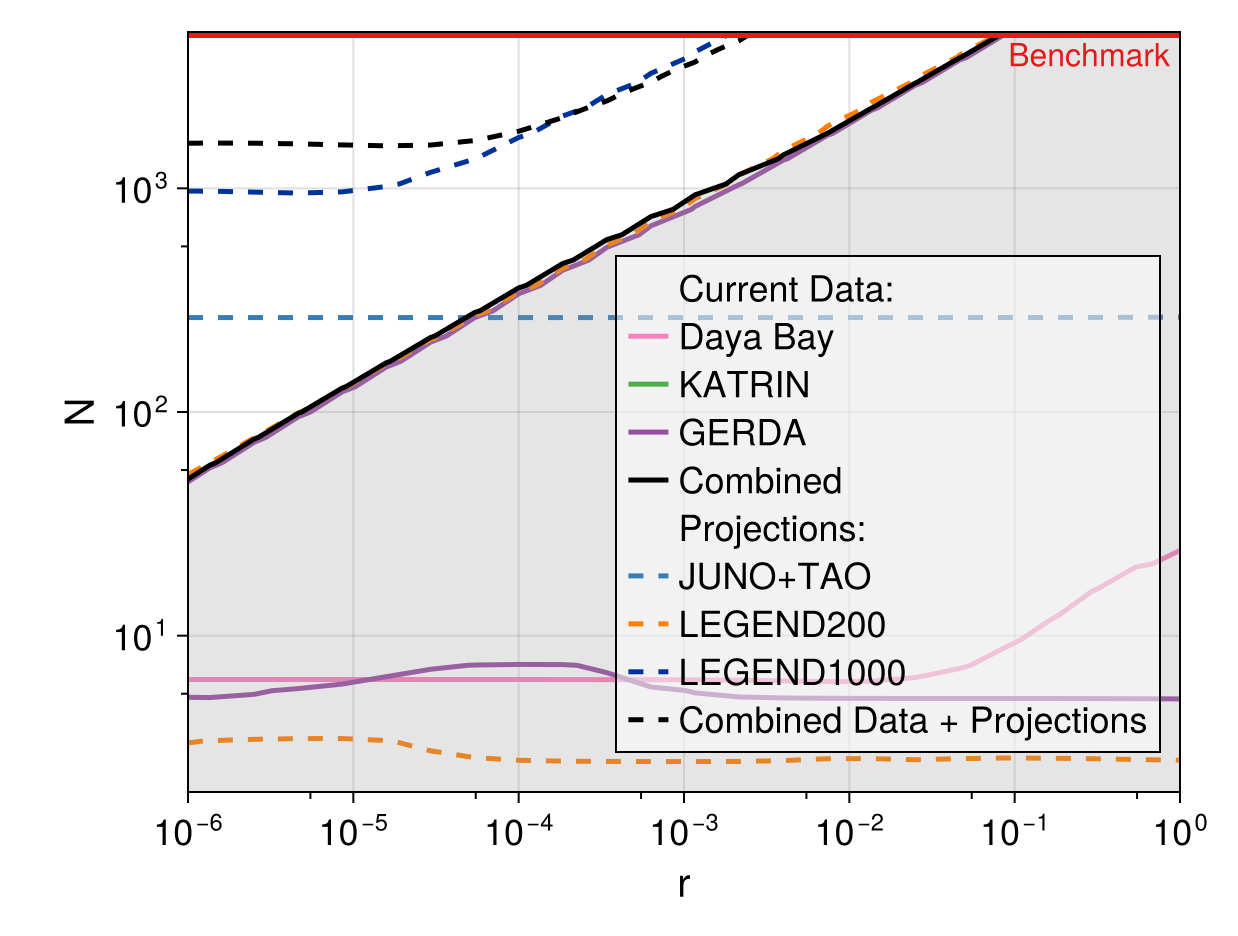

CairoMakie.Screen{IMAGE}


In [177]:
# NNM NO

file_paths = [
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/junotao_full6_rN_NNM_NO_prof_log9.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NNM_NO_sp_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/gerda5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/legend200_5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/legend1000_5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NNM_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_all_5000_rN_NNM_NO_prof_log_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10, 
    xlims = (1e-6, 1e0),
   title=nothing,#"Majorana NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","KATRIN","GERDA","LEGEND200","LEGEND1000","Combined Data", "Combined Data + Projections"],
   smooth_sigma=0.8
  
)

display(fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NNM_NO_new.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NNM_NO_new.svg", fig)

In [178]:
# Modified superpose_contours function with organized legend
function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=1.0
)

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    if experiments !== nothing
        # Force Daya Bay to use the 8th color from the colorscheme
        idx_dayabay = findfirst(==("Daya Bay"), experiments)
        if idx_dayabay !== nothing
            colors[idx_dayabay] = cs.colors[8]  # Get directly from colorscheme
        end
    end    

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = false,
        yminorgridvisible = false,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18
    )
    colsize!(fig.layout, 1, Relative(0.95))

    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed = i in [2,5,6,8]  # Index-based approach for projections
        # Projections: JUNO+TAO (2), LEGEND200 (5), LEGEND1000 (6), Combined Projection (8)

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        linecolor = if label == "Combined Data" || label == "Combined Data + Projections"
            :black
        else
            colors[i]
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    hlines!(ax, [4999.0], color=cs.colors[1]  , linewidth=6.0)
    text!(
        ax, 
        2e-6, #ax.finallimits[].widths[1],  # right edge of x-axis
       4800.0,
        text="Benchmark",
        align=(:left, :top),
        offset=(-5, 0),
        fontsize=16,
        color=cs.colors[1]
    )

    

    if experiments !== nothing
        # Create organized legend
        legend_elements = []
        legend_labels = []
        
        # Current Data section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Current Data:")
        
        push!(legend_elements, LineElement(color=colors[8], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Daya Bay")
        
        push!(legend_elements, LineElement(color=colors[3], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "KATRIN")
        
        push!(legend_elements, LineElement(color=colors[4], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "GERDA")
        
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Combined")
        
        # Projections section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Projections:")
        
        push!(legend_elements, LineElement(color=colors[2], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "JUNO+TAO")
        
        push!(legend_elements, LineElement(color=colors[5], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "LEGEND200")
        
        push!(legend_elements, LineElement(color=colors[6], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "LEGEND1000")
        
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "Combined Data + Projections")
        
        # Add legend
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            backgroundcolor=(:white, 0.5),
            tellwidth=false,
            tellheight=false,
            halign=:right,
            valign=:bottom,
            labelsize=18,
            margin=(10, 10, 20, 10)
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

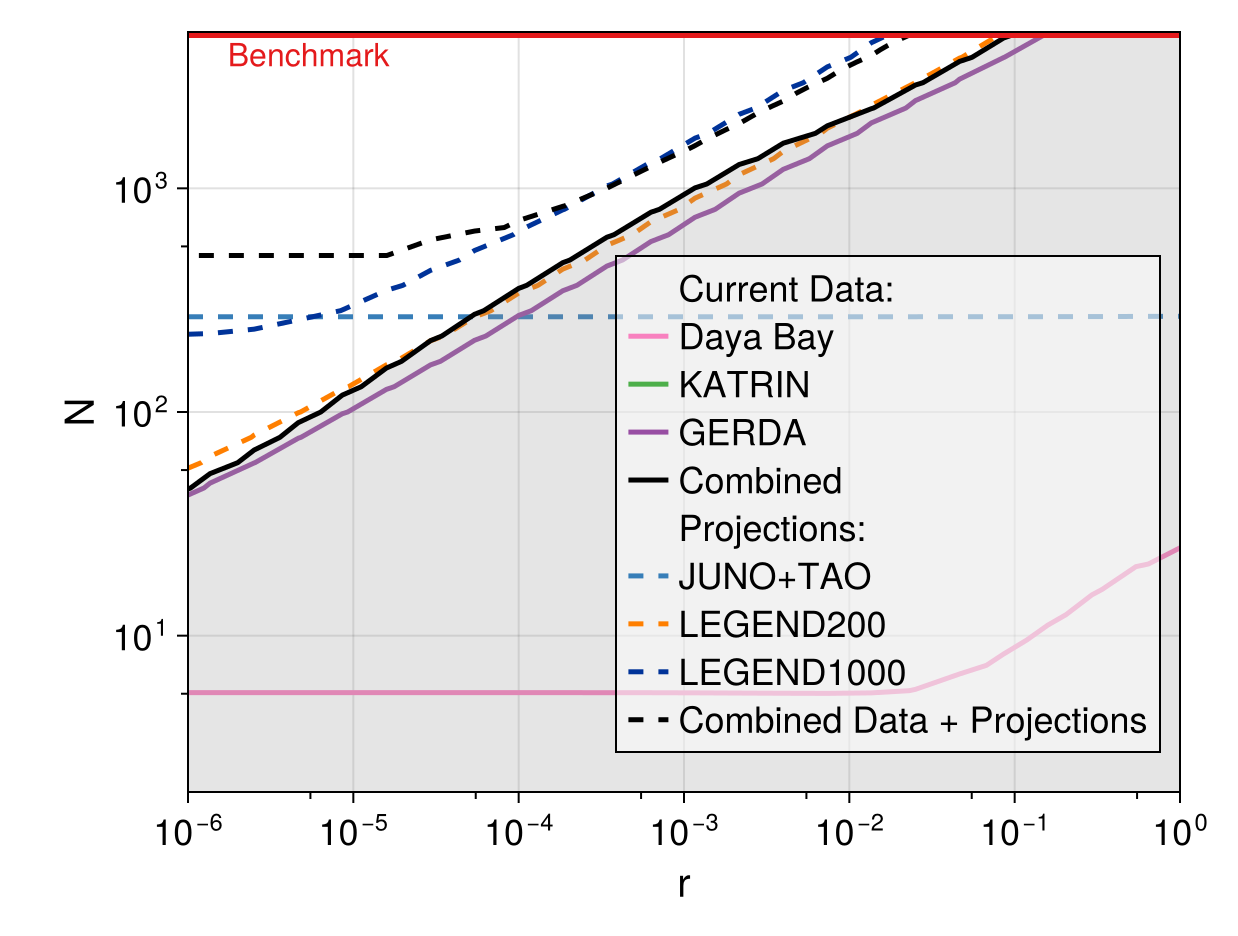

CairoMakie.Screen{IMAGE}


In [179]:
#NNM IO

file_paths = [
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/junotao_full6_rN_NNM_IO_prof_log9.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NNM_IO_sp_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/gerda5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/legend200_5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/legend1000_5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NNM_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_all_5000_rN_NNM_IO_prof_log_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
    xlims = (1e-6, 1e0),
   title="Majorana IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","KATRIN","GERDA","LEGEND200","LEGEND1000","Combined Data", "Combined Data + Projections"],
  smooth_sigma=0.8
)

display(fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NNM_IO_new1.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NNM_IO_new1.svg", fig)

In [145]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.2
)

    sigma_90 = quantile(Chisq(2), 0.90)  # Fixed: use sigma_90 consistently

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        # works for both load(fp)["result"]
        # and only(values(load(fp)))
        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))  # PRD single column: 8.6 cm width

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        #title = title,
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = true,
        yminorgridvisible = true,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18
    )
    colsize!(fig.layout, 1, Relative(0.95))  # Axis takes 95% of width
    
    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in ["JUNO+TAO", "LEGEND200", "LEGEND1000", "Combined Data + Projection"]

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        # --- COLOR FIX ---
        linecolor = if label == "Combined Data" || label == "Combined Data + Projection"
            :black
        else
            colors[i]  # Fixed: was colors[idx] but idx not defined
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,  # Fixed: use linecolor instead of colors[i] for consistency
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end
    
        # Add benchmark line at N = 5000
    hlines!(ax, [5000.0], color=:black, linewidth=3.0)
    text!(
        ax, 
        xlims(ax)[2],  # right edge of plot
        5000,  # y-position
        text="Benchmark",
        align=(:right, :bottom),
        offset=(-5, 0),
        fontsize=18,
        color=:black
    )

    if experiments !== nothing

        legend_elements = LineElement[]
        legend_labels = String[]

        for (i,label) in enumerate(experiments)

            force_dashed =
                label in ["JUNOTAO", "LEGEND200", "LEGEND1000", "Combined Data + Projection"]

            push!(
                legend_elements,
                LineElement(
                    color=colors[i],
                    linewidth=2.5,
                    linestyle=force_dashed ? :dot : :solid
                )
            )

            push!(legend_labels, label)
        end

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=2.5,
            linestyle=:solid,
           # points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Data")

        push!(legend_elements, LineElement(
            color=:black,
            linewidth=2.5,
            linestyle=:dot,
          #  points=Point2f[(0,0),(1.3,0)]
        ))
        push!(legend_labels, "Combined Data + Projection")

        
        # style explanation
      
        #keep_labels = Set(["Daya Bay","JUNOTAO","KATRIN","GERDA","LEGEND200","LEGEND1000", "Combined Data", "Combined Data + Projection"])

        #filtered_indices = [i for (i, label) in enumerate(experiments) if label in keep_labels]
        
        keep=[1,2,3,6,7]
        Legend(
            fig[1,1],
            legend_elements[keep],
            legend_labels[keep];
            tellwidth=false,
            tellheight=false,
            halign=:left,
            valign=:bottom,
            labelsize=18,  # Increased from 9 to 14 (matches tick labels)
            framevisible=true,
            backgroundcolor=(:white, 0.95),
            strokecolor=:black,
            strokewidth=0.5
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

In [171]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering
using ImageFiltering.Kernel

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.2
)

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    if experiments !== nothing
        # Force Daya Bay to use the 8th color from the colorscheme
        idx_dayabay = findfirst(==("Daya Bay"), experiments)
        if idx_dayabay !== nothing
            colors[idx_dayabay] = cs.colors[8]  # Get directly from colorscheme
        end
    end    

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = false,
        yminorgridvisible = false,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18
    )
    colsize!(fig.layout, 1, Relative(0.95))
    
    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in ["JUNO+TAO", "JUNOTAO", "LEGEND200", "LEGEND1000", "Combined Data + Projections"]

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        linecolor = if label == "Combined Data" || label == "Combined Data + Projections"
            :black
        else
            colors[i]
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    
    hlines!(ax, [4999.0], color=cs.colors[1]  , linewidth=6.0)
    text!(
        ax, 
        ax.finallimits[].widths[1],  # right edge of x-axis
       4800.0,
        text="Benchmark",
        align=(:right, :top),
        offset=(-5, 0),
        fontsize=16,
        color=cs.colors[1]
    )


    if experiments !== nothing
        # Create organized legend
        legend_elements = []
        legend_labels = []
        
        # Current Data section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Current Data:")
        
        # Add current data experiments (indices 1, 3, 7 based on your keep array)
        push!(legend_elements, LineElement(color=colors[1], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Daya Bay")
        
        push!(legend_elements, LineElement(color=colors[3], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "KATRIN")
        
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Combined Data")
        
        # Projections section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Projections:")
        
        # Add projection experiments (indices 2, 6 based on your keep array)
        push!(legend_elements, LineElement(color=colors[2], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "JUNO+TAO")
      
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "Combined Data + Projections")
        
        # Add legend
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth=false,
            tellheight=false,
            halign=:left,
            valign=:bottom,
            labelsize=18,
            framevisible=true,
            backgroundcolor=(:white, 0.5),
            strokecolor=:black,
            strokewidth=0.5,
            margin=(10, 10, 40, 10)
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

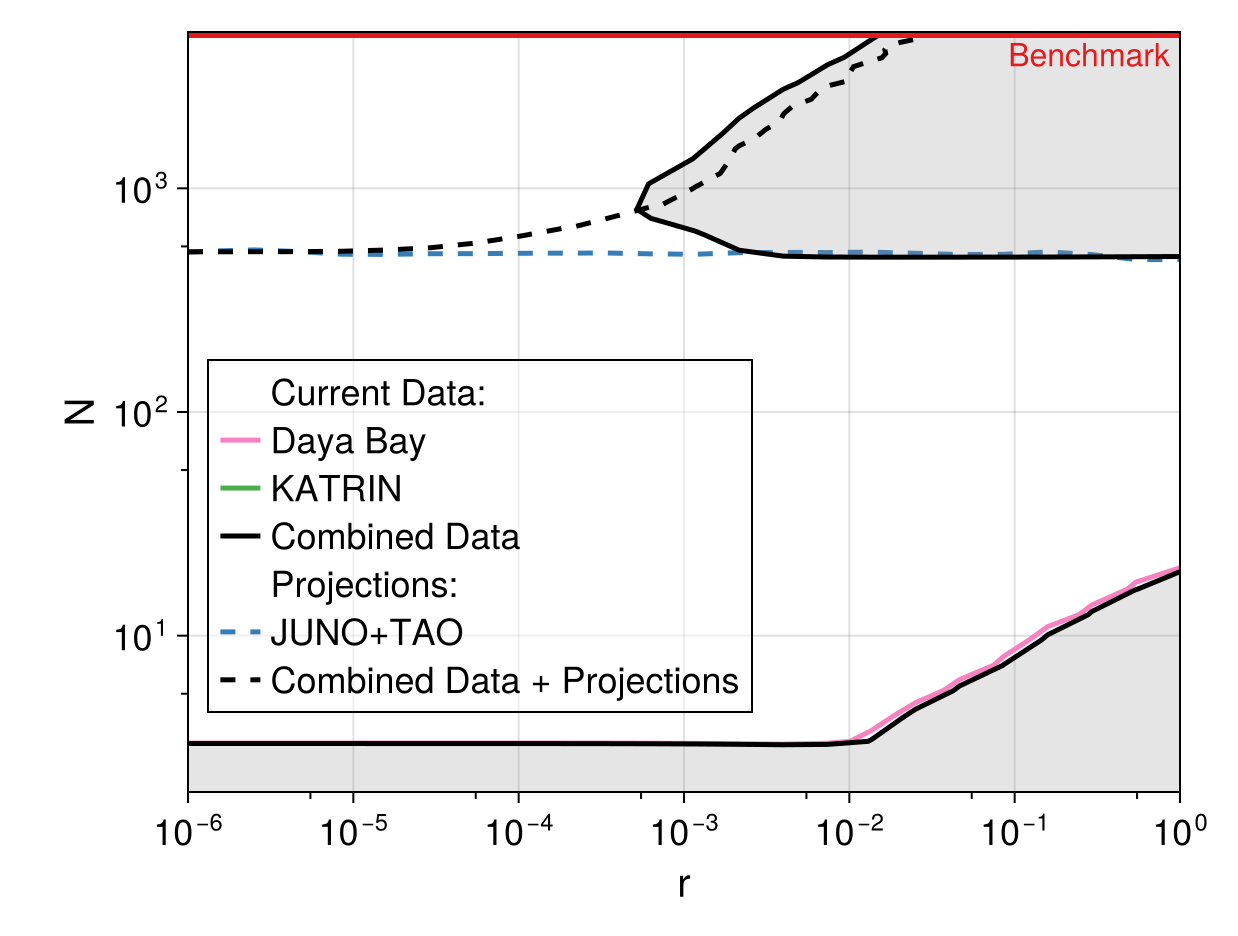

CairoMakie.Screen{IMAGE}


In [172]:
#NND NO

file_paths = [
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NND_NO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/junotao_full6_rN_NND_NO_prof_log9.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_NO_sp_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_NO_logdamp_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_all_5000_rN_NND_NO_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
     xlims = (1e-6, 1e0),
     title=nothing,#"Dirac NO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","KATRIN","Combined Data", "Combined Data + Projections"],
   smooth_sigma=0.8

  
)

display(fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NND_NO_new.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NND_NO_new.svg", fig)

In [173]:
using JLD2
using CairoMakie
using Distributions
using Colors
using ColorSchemes
using ImageFiltering
using ImageFiltering.Kernel

function superpose_contours(
    file_paths::Vector{String};
    title=nothing,
    experiments=nothing,
    colorscheme=:Set1_9,
    color_step=1,
    xscale=identity,
    yscale=identity,
    xlims=nothing,
    ylims=nothing,
    smooth_sigma::Union{Nothing,Float64}=0.2
)

    sigma_90 = quantile(Chisq(2), 0.90)

    results = []
    all_x = []
    all_y = []

    for fp in file_paths
        data = load(fp)

        result = haskey(data, "result") ?
            data["result"] :
            only(values(data))

        push!(results, result)
        push!(all_x, result.axes[1])
        push!(all_y, result.axes[2])
    end

    x_min = minimum(minimum.(all_x))
    x_max = maximum(maximum.(all_x))
    y_min = minimum(minimum.(all_y))
    y_max = maximum(maximum.(all_y))

    axis_labels = collect(keys(results[1].axes))

    cs = getproperty(ColorSchemes, colorscheme)
    colors = cs.colors[1:color_step:end]
    colors = colors[1:length(results)]

    if experiments !== nothing
        # Force Daya Bay to use the 8th color from the colorscheme
        idx_dayabay = findfirst(==("Daya Bay"), experiments)
        if idx_dayabay !== nothing
            colors[idx_dayabay] = cs.colors[8]  # Get directly from colorscheme
        end
    end    

    # Optional custom color
    if experiments !== nothing
        idx = findfirst(==("LEGEND1000"), experiments)
        if idx !== nothing
            colors[idx] = RGB(0.0,0.2,0.6)
        end
    end

    fig = Figure(size=(8.6*72, 6.5*72))

    ax = Axis(
        fig[1,1],
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        xscale = xscale,
        yscale = yscale,
        xminorticksvisible = true,
        yminorticksvisible = true,
        xminorgridvisible = false,
        yminorgridvisible = false,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18
    )
    colsize!(fig.layout, 1, Relative(0.95))
    
    for (i,result) in enumerate(results)

        lp = result.values.log_posterior

        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH =
            smooth_sigma === nothing ?
            dLLH_raw :
            imfilter(
                dLLH_raw,
                Kernel.gaussian(smooth_sigma)
            )

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        label =
            experiments === nothing ?
            "" :
            experiments[i]

        force_dashed =
            label in ["JUNO+TAO", "JUNOTAO", "LEGEND200", "LEGEND1000", "Combined Data + Projections"]

        # Get maxlevel for contourf
        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6

        if label == "Combined Data"
            if isfinite(maxlevel) && maxlevel > sigma_90 + ϵ
                contourf!(ax,
                    result.axes[1],
                    result.axes[2],
                    dLLH_plot;
                    levels = [sigma_90, maxlevel],
                    colormap = cgrad([RGBA(0.6,0.6,0.6,0.25),
                                      RGBA(0.6,0.6,0.6,0.25)])
                )
            end
        end
        
        linecolor = if label == "Combined Data" || label == "Combined Data + Projections"
            :black
        else
            colors[i]
        end

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels=[sigma_90],
            color=linecolor,
            linewidth=2.5,
            linestyle=force_dashed ? :dash : :solid
        )
    end

    if xlims === nothing
        xlims!(ax, x_min, x_max)
    else
        xlims!(ax, xlims)
    end

    if ylims === nothing
        ylims!(ax, y_min, y_max)
    else
        ylims!(ax, ylims)
    end

    
    hlines!(ax, [4999.0], color=cs.colors[1]  , linewidth=6.0)
    text!(
        ax, 
        2e-6,#ax.finallimits[].widths[1],  # right edge of x-axis
       4800.0,
        text="Benchmark",
        align=(:left, :top),
        offset=(-5, 0),
        fontsize=16,
        color=cs.colors[1]
    )


    if experiments !== nothing
        # Create organized legend
        legend_elements = []
        legend_labels = []
        gridshifts = []  # Control column placement
        
        # Current Data section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Current Data:")
        push!(gridshifts, 0)
        
        
        # Projections section
        push!(legend_elements, LineElement(color=:transparent, linewidth=0))
        push!(legend_labels, "Projections:")
        push!(gridshifts, 0)
        # Add current data experiments (indices 1, 3, 7 based on your keep array)
        push!(legend_elements, LineElement(color=colors[1], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Daya Bay")
         push!(gridshifts, 0)
        
         
        
        # Add projection experiments (indices 2, 6 based on your keep array)
        push!(legend_elements, LineElement(color=colors[2], linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "JUNO+TAO")
        push!(gridshifts, 1)

        push!(legend_elements, LineElement(color=colors[3], linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "KATRIN")
         push!(gridshifts, 0)
         
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:dash))
        push!(legend_labels, "Combined Data + Projections")
        push!(gridshifts, 1)
        
        push!(legend_elements, LineElement(color=:black, linewidth=2.5, linestyle=:solid))
        push!(legend_labels, "Combined Data")
        push!(gridshifts, 0)
        
      
        
        # Add legend
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth=false,
            tellheight=false,
            halign=:left,
            valign=:bottom,
            labelsize=18,
            framevisible=true,
            backgroundcolor=(:white, 0.5),
            strokecolor=:black,
            strokewidth=0.5,
            margin=(10, 10, 20, 10),
            gridshifts=gridshifts,
            nbanks=2,  # Display in 2 columns
            orientation=:vertical  # Each bank is vertical
            
        )
    end

    return fig
end

superpose_contours (generic function with 1 method)

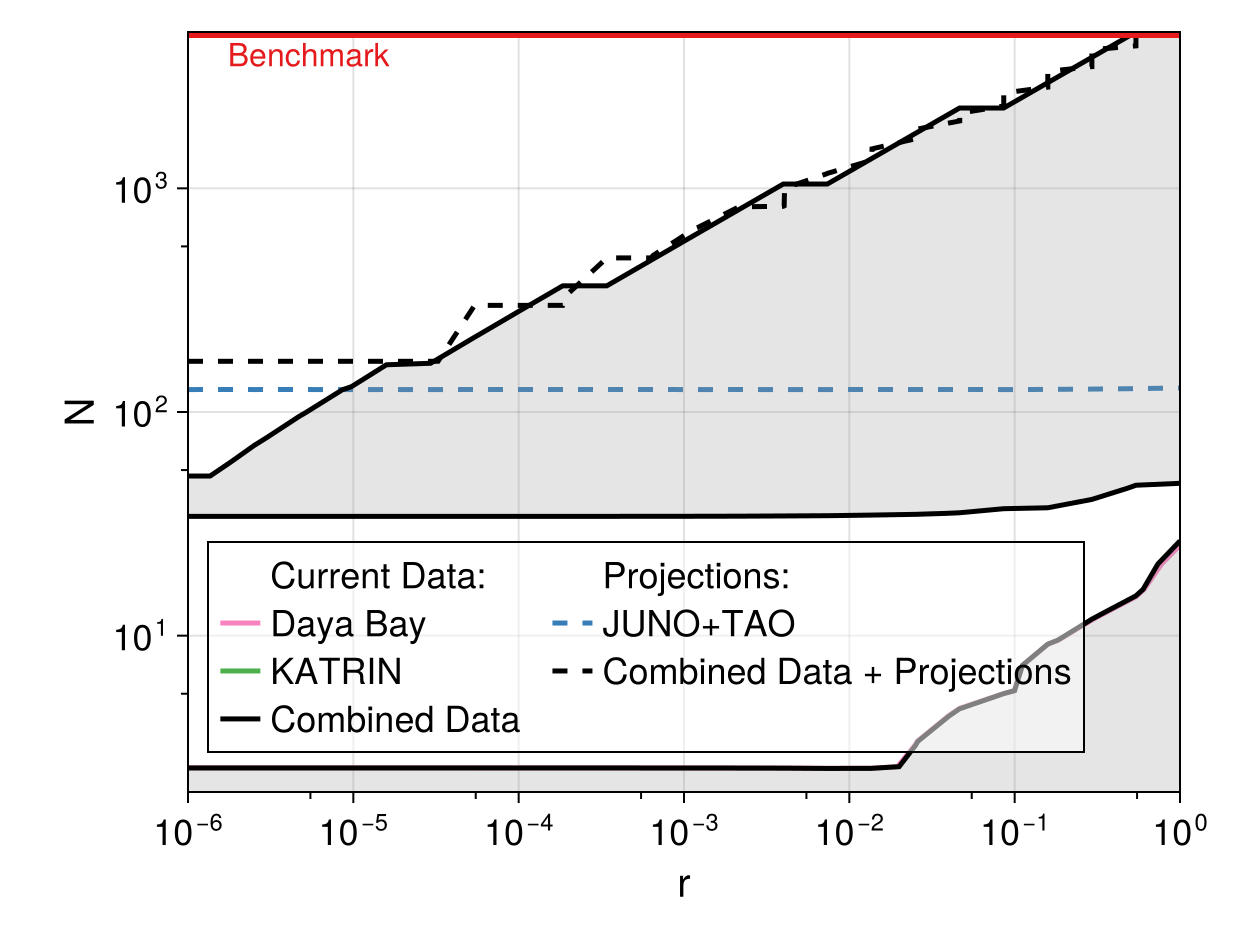

CairoMakie.Screen{IMAGE}


In [174]:
# NND IO

file_paths = [
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/dayabay_5000_rN_NND_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/junotao_full6_rN_NND_IO_prof_log9.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/katrin5000_rN_NND_IO_sp_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_data_5000_rN_NND_IO_log_m0=0.01.jld2",
"/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/global_all_5000_rN_NND_IO_m0=0.01.jld2",
]


fig = superpose_contours(
   file_paths;
    xscale=log10,
    yscale=log10,
    xlims = (1e-6, 1e0),
     
   title=nothing,#"Dirac IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
   experiments=["Daya Bay","JUNO+TAO","KATRIN","Combined Data", "Combined Data + Projections"],
   smooth_sigma=0.2

  
)

display(fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NND_IO_new.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_NND_IO_new.svg", fig)

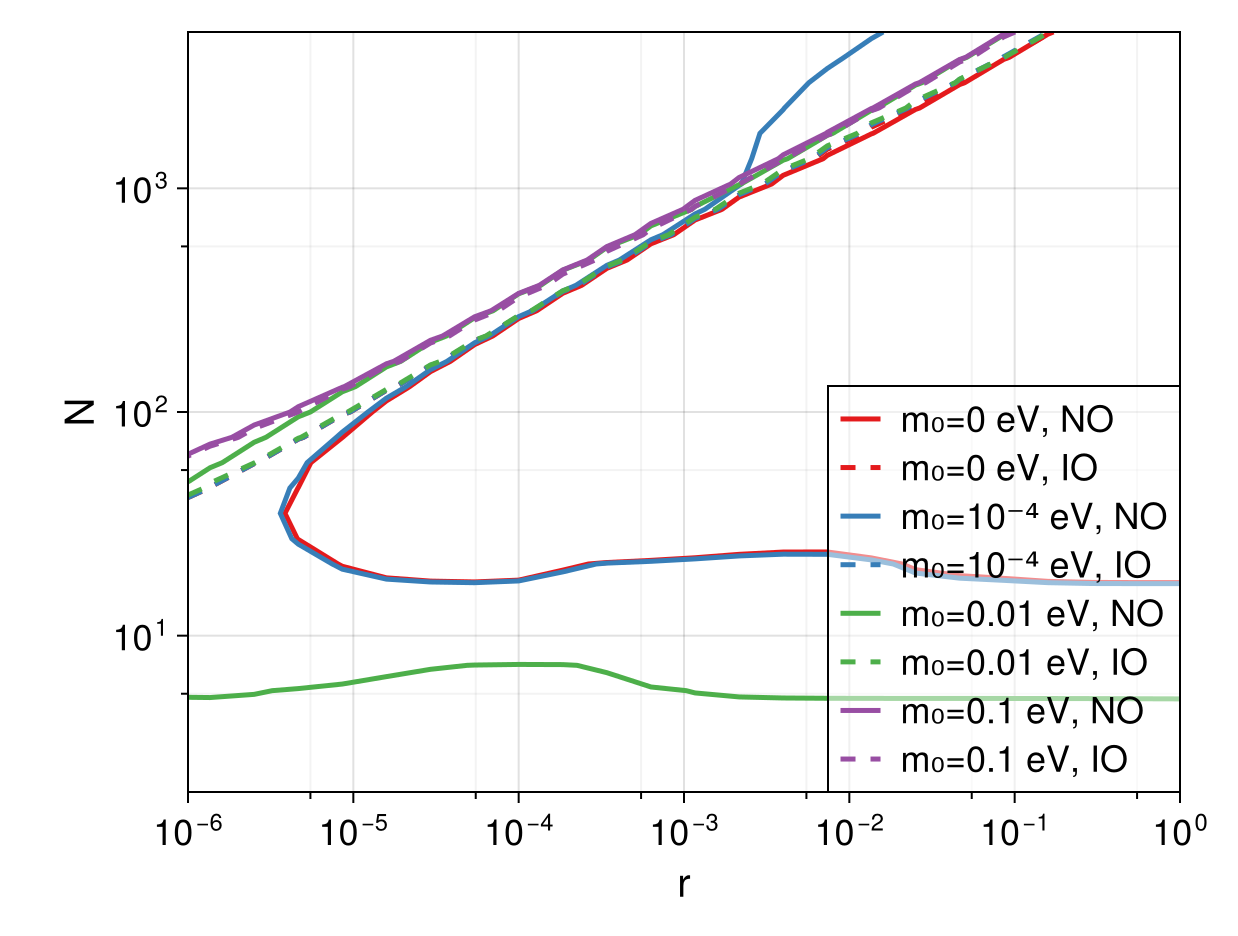

CairoMakie.Screen{IMAGE}


In [161]:
# m0 effect

using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end

function superpose_contours_singlepanel(
    file_groups::Vector{Vector{String}};
    title = "",
    m0_labels = ["0 eV", "10⁻⁴ eV", "0.01 eV", "0.1 eV"],
    experiments = nothing,
    colorscheme = nothing,
    color_step = 1,
    xscale = identity,
    yscale = identity,
    xlims = nothing,
    ylims = nothing,
    smooth_sigma::Union{Nothing,Float64} = nothing,
)

    # ---------------- Defaults ----------------
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end

    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)

    # ---------------- Figure ----------------
    fig = Figure(size=(8.6*72, 6.5*72))  # PRD single column: 8.6 cm width

    # ---------- Load all results to determine ranges ----------
    all_results = []
    all_axes_1 = []
    all_axes_2 = []
    all_m0_indices = []
    all_neutrino_types = []

    for (m0_idx, file_paths) in enumerate(file_groups)
        for file_path in file_paths
            data = load(file_path)
            result = only(values(data))
            
            push!(all_results, result)
            push!(all_axes_1, result.axes[1])
            push!(all_axes_2, result.axes[2])
            push!(all_m0_indices, m0_idx)
            
            # Determine neutrino type from filename
            if contains(file_path, "NO")
                push!(all_neutrino_types, "NO")
            elseif contains(file_path, "IO")
                push!(all_neutrino_types, "IO")
            else
                push!(all_neutrino_types, "unknown")
            end
        end
    end

    # ---------- Axis ranges ----------
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])

    # ---------- Labels ----------
    first_result = all_results[1]
    axis_labels = collect(keys(first_result.axes))

    # ---------- Axis ----------
    ax = Axis(fig[1, 1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        xminorgridvisible = true,
        yminorticksvisible = true,
        yminorgridvisible = true,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
    colsize!(fig.layout, 1, Relative(0.95))  # Axis takes 95% of width
    
    if xlims !== nothing
        if ylims !== nothing
            limits!(ax, xlims[1], xlims[2], ylims[1], ylims[2])
        else
            limits!(ax, xlims[1], xlims[2], y_min, y_max)
        end
    elseif ylims !== nothing
        limits!(ax, x_min, x_max, ylims[1], ylims[2])
    else
        limits!(ax, x_min, x_max, y_min, y_max)
    end

    # ---------- Colors for different m0 values ----------
    n_m0_values = length(file_groups)
    colors = all_colors[1:color_step:n_m0_values]
    
    if n_m0_values > length(colors)
        colors = [colors[i] for i in round.(Int, range(1, length(colors), length=n_m0_values))]
    else
        colors = colors[1:n_m0_values]
    end

    # ---------- Plot contours ----------
    for (idx, result) in enumerate(all_results)
        m0_idx = all_m0_indices[idx]
        neutrino_type = all_neutrino_types[idx]
        
        dLLH_raw = 2 .* (
            maximum(result.values.log_posterior)
            .- result.values.log_posterior
        )

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        
        color = colors[m0_idx]
        # Set line style based on neutrino type
        linestyle = neutrino_type == "NO" ? :solid : :dash
        
        color_transparent = RGBA(color, 0.8)
        color_transparent_full = RGBA(color, 0.1)

       #= if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + 1e-6
            contourf!(
                ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        en=#

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
    end

    # ---------- Create legend with proper box style ----------
    legend_elements = LineElement[]
    legend_labels = String[]
    
    # Add legend entries for each m0 value and hierarchy
    for m0_idx in 1:length(file_groups)
        # NO entry
        push!(legend_elements, LineElement(
            color = colors[m0_idx],
            linewidth = 2.5,
            linestyle = :solid
        ))
        push!(legend_labels, " m₀=$(m0_labels[m0_idx]), NO")
        
        # IO entry
        push!(legend_elements, LineElement(
            color = colors[m0_idx],
            linewidth = 2.5,
            linestyle = :dash
        ))
        push!(legend_labels, " m₀=$(m0_labels[m0_idx]), IO")
    end
    
    # Add legend to the figure (positioned at bottom-right to avoid overlap)
    Legend(
        fig[1,1],
        legend_elements,
        legend_labels;
        tellwidth = false,
        tellheight = false,
        halign = :right,
        valign = :bottom,
        labelsize = 18,
        framevisible = true,
        backgroundcolor = (:white, 0.5),
        strokecolor = :black,
        strokewidth = 0.5
    )

    return fig
end

# ---------- File groups ----------
group1 = [
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.0_NNM_NO_5000_log.jld2",
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.0_NNM_IO_5000_log.jld2"
]

group2 = [
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.0001_NNM_NO_5000_log.jld2",
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.0001_NNM_IO_5000_log.jld2"
]

group3 = [
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.01_NNM_NO_5000_log.jld2",
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.01_NNM_IO_5000_log.jld2"
]

group4 = [
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.1_NNM_NO_5000_log.jld2",
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.1_NNM_IO_5000_log.jld2"
]

# ---------- Create single-panel figure ----------
fig = superpose_contours_singlepanel(
    [group1, group2, group3, group4];
    title = "",
    m0_labels = ["0 eV", "10⁻⁴ eV", "0.01 eV", "0.1 eV"],
    colorscheme = :Set1_9,
    xscale = log10,
    yscale = log10,
    xlims = (1e-6, 1e0),
    smooth_sigma = 0.8,
    color_step = 1
)

# ---------- Save and display the figure ----------
display(fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_gerda_all_m0_new.png", fig)
#   save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_gerda_all_m0_new.svg", fig)

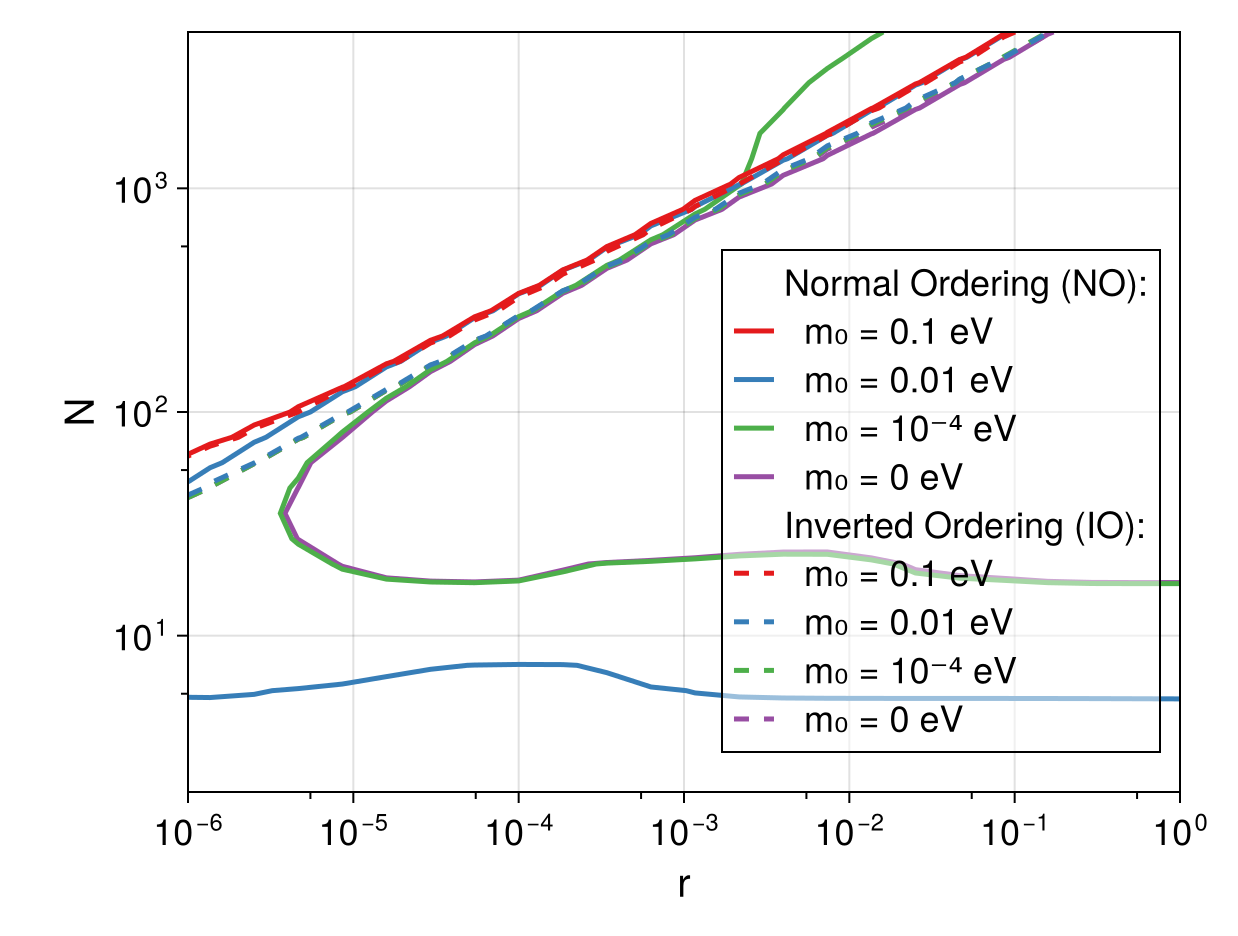

CairoMakie.Screen{SVG}


In [164]:
# m0 effect

using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end

function superpose_contours_singlepanel(
    file_groups::Vector{Vector{String}};
    title = "",
    m0_labels = ["0 eV", "10⁻⁴ eV", "0.01 eV", "0.1 eV"],
    experiments = nothing,
    colorscheme = nothing,
    color_step = 1,
    xscale = identity,
    yscale = identity,
    xlims = nothing,
    ylims = nothing,
    smooth_sigma::Union{Nothing,Float64} = nothing,
)

    # ---------------- Defaults ----------------
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end

    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors

    sigma_90_excluded_level = quantile(Chisq(2), 0.90)

    # ---------------- Figure ----------------
    fig = Figure(size=(8.6*72, 6.5*72))  # PRD single column: 8.6 cm width

    # ---------- Load all results to determine ranges ----------
    all_results = []
    all_axes_1 = []
    all_axes_2 = []
    all_m0_indices = []
    all_neutrino_types = []

    for (m0_idx, file_paths) in enumerate(file_groups)
        for file_path in file_paths
            data = load(file_path)
            result = only(values(data))
            
            push!(all_results, result)
            push!(all_axes_1, result.axes[1])
            push!(all_axes_2, result.axes[2])
            push!(all_m0_indices, m0_idx)
            
            # Determine neutrino type from filename
            if contains(file_path, "NO")
                push!(all_neutrino_types, "NO")
            elseif contains(file_path, "IO")
                push!(all_neutrino_types, "IO")
            else
                push!(all_neutrino_types, "unknown")
            end
        end
    end

    # ---------- Axis ranges ----------
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])

    # ---------- Labels ----------
    first_result = all_results[1]
    axis_labels = collect(keys(first_result.axes))

    # ---------- Axis ----------
    ax = Axis(fig[1, 1];
        xlabel = String(axis_labels[1]),
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true,
        #xminorgridvisible = true,
        yminorticksvisible = true,
        #yminorgridvisible = true,
        titlesize = 18,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
    colsize!(fig.layout, 1, Relative(0.95))  # Axis takes 95% of width
    
    if xlims !== nothing
        if ylims !== nothing
            limits!(ax, xlims[1], xlims[2], ylims[1], ylims[2])
        else
            limits!(ax, xlims[1], xlims[2], y_min, y_max)
        end
    elseif ylims !== nothing
        limits!(ax, x_min, x_max, ylims[1], ylims[2])
    else
        limits!(ax, x_min, x_max, y_min, y_max)
    end

    # ---------- Colors for different m0 values ----------
    n_m0_values = length(file_groups)
    colors = all_colors[1:color_step:n_m0_values]
    
    if n_m0_values > length(colors)
        colors = [colors[i] for i in round.(Int, range(1, length(colors), length=n_m0_values))]
    else
        colors = colors[1:n_m0_values]
    end

    # Reverse colors so highest mass (m0=0.1 eV) gets first color
    colors = reverse(colors)

    # ---------- Plot contours ----------
    for (idx, result) in enumerate(all_results)
        m0_idx = all_m0_indices[idx]
        neutrino_type = all_neutrino_types[idx]
        
        dLLH_raw = 2 .* (
            maximum(result.values.log_posterior)
            .- result.values.log_posterior
        )

        dLLH = smooth_sigma === nothing ?
            dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        
        # Use reversed color index
        color = colors[m0_idx]
        # Set line style based on neutrino type
        linestyle = neutrino_type == "NO" ? :solid : :dash
        
        color_transparent = RGBA(color, 0.8)
        color_transparent_full = RGBA(color, 0.1)

        contour!(
            ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
    end

    # ---------- Create legend with NO first (highest to lowest mass), then IO (highest to lowest mass) ----------
    legend_elements = LineElement[]
    legend_labels = String[]
    
    # First: NO entries (from highest to lowest mass)
    push!(legend_elements, LineElement(color=:transparent, linewidth=0))
    push!(legend_labels, "Normal Ordering (NO):")
    
    for m0_idx in length(file_groups):-1:1  # Reverse order: highest mass first
        push!(legend_elements, LineElement(
            color = colors[m0_idx],
            linewidth = 2.5,
            linestyle = :solid
        ))
        push!(legend_labels, "  m₀ = $(m0_labels[m0_idx])")
    end
    
    # Then: IO entries (from highest to lowest mass)
    push!(legend_elements, LineElement(color=:transparent, linewidth=0))
    push!(legend_labels, "Inverted Ordering (IO):")
    
    for m0_idx in length(file_groups):-1:1  # Reverse order: highest mass first
        push!(legend_elements, LineElement(
            color = colors[m0_idx],
            linewidth = 2.5,
            linestyle = :dash
        ))
        push!(legend_labels, "  m₀ = $(m0_labels[m0_idx])")
    end
    
    # Add legend to the figure (positioned at bottom-right to avoid overlap)
    Legend(
        fig[1,1],
        legend_elements,
        legend_labels;
        tellwidth = false,
        tellheight = false,
        halign = :right,
        valign = :bottom,
        labelsize = 18,
        framevisible = true,
        backgroundcolor = (:white, 0.5),
        strokecolor = :black,
        strokewidth = 0.5,
        margin = (10, 10, 20, 10)
    )

    return fig
end

# ---------- File groups ----------
group1 = [
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.0_NNM_NO_5000_log.jld2",
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.0_NNM_IO_5000_log.jld2"
]

group2 = [
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.0001_NNM_NO_5000_log.jld2",
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.0001_NNM_IO_5000_log.jld2"
]

group3 = [
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.01_NNM_NO_5000_log.jld2",
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.01_NNM_IO_5000_log.jld2"
]

group4 = [
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.1_NNM_NO_5000_log.jld2",
    "/home/sofialon/Newtrinos.jl/scan_plot_paper/scan/scan_gerda_rN_m0=0.1_NNM_IO_5000_log.jld2"
]

# ---------- Create single-panel figure ----------
fig = superpose_contours_singlepanel(
    [group1, group2, group3, group4];
    title = "",
    m0_labels = ["0 eV", "10⁻⁴ eV", "0.01 eV", "0.1 eV"],
    colorscheme = :Set1_9,
    xscale = log10,
    yscale = log10,
    xlims = (1e-6, 1e0),
    smooth_sigma = 0.8,
    color_step = 1
)

# ---------- Save and display the figure ----------
display(fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_gerda_all_m0_new.png", fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/plot/superposed_contours_gerda_all_m0_new.svg", fig)

KATRIN plots

In [11]:
using LinearAlgebra
using Distributions
using FileIO
import JLD2
using DataFrames
using CairoMakie

#NNATURALNESS 

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   katrin= Newtrinos.katrin.configure(physics),
);

par= Newtrinos.get_params(experiments)

matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)

[ Info: Loading Katrin data


(ComplexF64[-0.8168935499694263 + 0.0im -0.5437108972831824 + 0.0im … -0.05415481330424365 + 0.0im -0.007734335334724904 + 0.012045513595371924im; 0.40914300190845243 + 0.07600818142539172im -0.5089043221386129 + 0.05058979413561212im … -0.050688001091847346 + 0.005038855888678794im -0.07379132405527435 + 0.0im; … ; -0.009318757440194933 - 0.0017311839695892956im 0.01159094965856872 - 0.0011522475474348964im … -0.22494357424949074 + 0.02236147074874111im -0.3274716663519327 + 0.0im; 0.00848377502254429 - 0.0015036266758122363im -0.014839528942619739 - 0.0010007891592673215im … 0.2879881958648625 + 0.019422143757592047im -0.2844268094836078 + 0.0im], [0.0, 7.737972471822558e-5, 0.0025436657715142592, 0.0001974162104815563, 0.00042345034169239375, 0.007627725440045777, 0.00039457509809140526, 0.0007690698716724589, 0.012705158272662213, 0.0005910461804015519  …  0.03297253584705333, 0.001380966079715625, 0.0024982132624597163, 0.038107685222430736, 0.0015849618426020157, 0.00285581783479

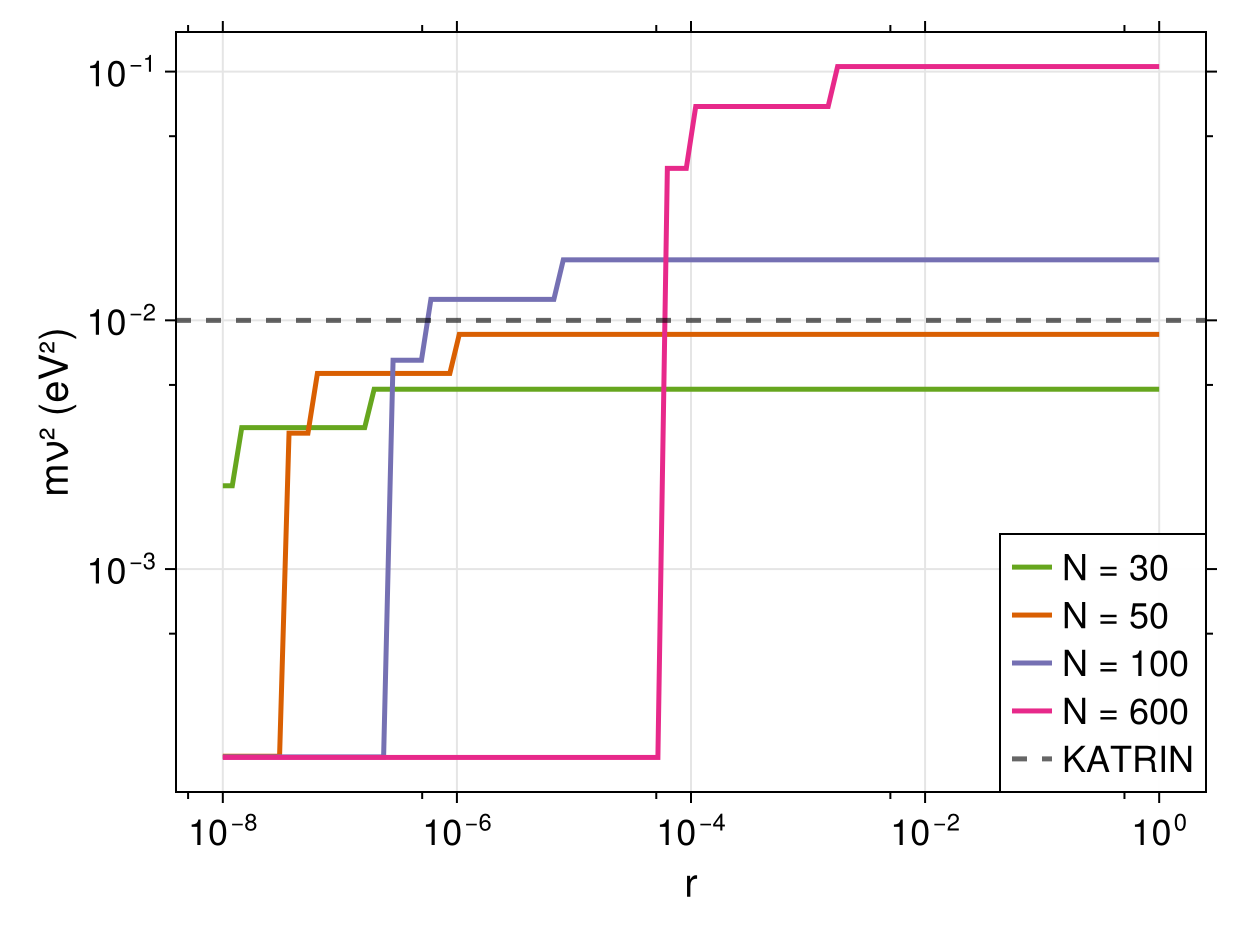

CairoMakie.Screen{IMAGE}


In [169]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

r_range = logrange(1e-8, 1, 100)

m1 = Float64[]
m2 = Float64[]
m3 = Float64[]
m4 = Float64[]

par = merge(par, (m₀ = 0.01,))
m0 = par.m₀

# ===================== COMPUTATION =====================

f = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)

for r in r_range
    for (N, container) in zip((30, 50, 100, 600), (m1, m2, m3, m4))
        p = merge(par, (r = r,), (N = N,))
        push!(container, f(p))
    end
end

# ===================== COLORS (ORIGINAL ASSIGNMENTS PRESERVED) =====================

cs = ColorSchemes.Dark2_8
c_N30  = cs[5]   # N = 30
c_N50  = cs[2]   # N = 50
c_N100 = cs[3]   # N = 100
c_N200 = cs[4]   # N = 200

# ===================== FIGURE - PRD STYLE =====================

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")  # PRD single column width

ax = Axis(
    fig[1, 1],
    #title = "Effective neutrino mass mν² vs r - NND, NO - m₀ = $(m0) eV, η = 1 + 1/N",
    xlabel = "r",
    ylabel = "mν² (eV²)",
    xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    xminorgridvisible = false,
    yminorticksvisible = true,
    yminorgridvisible = false,
    titlesize = 18,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

# ===================== PLOT =====================

for (data, color, label) in zip(
    (m1, m2, m3, m4),
    (c_N30, c_N50, c_N100, c_N200),
    ("N = 30", "N = 50", "N = 100", "N = 600")
)
    lines!(ax, r_range, data;
        color = color,
        linewidth = 2.5,
        label = label,
    )
end

hlines!(ax, 0.01;
    linestyle = :dash,
    linewidth = 2.5,
    color = (:black, 0.6),
    label = "KATRIN limit"
)

# ===================== LEGEND WITH BOX =====================

# Create legend elements
legend_elements = [
    LineElement(color = c_N30, linewidth = 2.5, linestyle = :solid),
    LineElement(color = c_N50, linewidth = 2.5, linestyle = :solid),
    LineElement(color = c_N100, linewidth = 2.5, linestyle = :solid),
    LineElement(color = c_N200, linewidth = 2.5, linestyle = :solid),
    LineElement(color = (:black, 0.6), linewidth = 2.5, linestyle = :dash)
]

legend_labels = ["N = 30", "N = 50", "N = 100", "N = 600", "KATRIN"]

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "N values",
    titlefont = :bold,
    titlesize = 16
)

# Display and save
display(fig)

save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_r.png", fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_r.svg", fig)

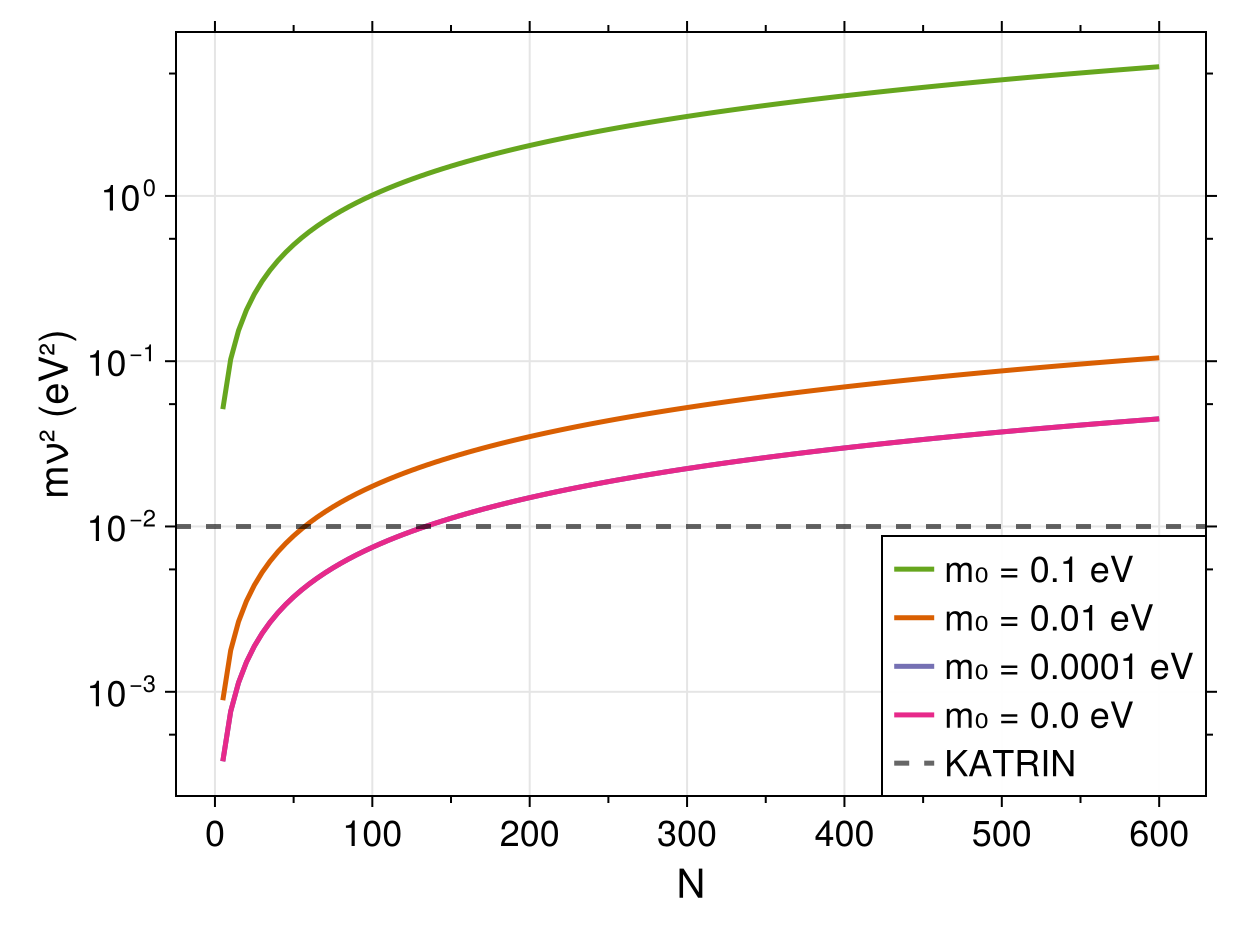

CairoMakie.Screen{SVG}


In [170]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

N_range  = range(5, 600, length = 120)
m0_values = [0.1, 0.01, 1e-4, 0.0]
r = 1

mass_by_m0 = Dict(m0 => Float64[] for m0 in m0_values)

f = Newtrinos.katrin.get_neutrinomass(osc_cfg.flavour)

# ===================== COMPUTATION =====================

for N in N_range
    for m0 in m0_values
        par_p = merge(par, (m₀ = m0, r = r, N = N))
        push!(mass_by_m0[m0], f(par_p))
    end
end

# ===================== COLORS (ORIGINAL ASSIGNMENTS PRESERVED) =====================

cs = ColorSchemes.Dark2_8
colors = Dict(
    0.1    => cs[5],
    0.01   => cs[2],
    1e-4  => cs[3],
    0.0   => cs[4]
)

c_lim = :black

# ===================== FIGURE - PRD STYLE =====================

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif") # PRD single column width

ax = Axis(
    fig[1, 1],
    #title = "Effective neutrino mass mν² vs N - NND, NO - r=1, η = 1 + 1/N",
    xlabel = "N",
    ylabel = "mν² (eV²)",
    #xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
   # xminorgridvisible = true,
    yminorticksvisible = true,
    #yminorgridvisible = true,
    titlesize = 18,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

# ===================== PLOTS =====================

for m0 in m0_values
    lines!(
        ax,
        N_range,
        mass_by_m0[m0];
        label = "m₀ = $(m0) eV",
        linewidth = 2.5,
        color = colors[m0]
    )
end

hlines!(ax, 0.01;
    linestyle = :dash,
    linewidth = 2.5,
    color = (:black, 0.6),
    label = "KATRIN limit"
)

# ===================== LEGEND WITH BOX =====================

# Create legend elements
legend_elements = []
legend_labels = []

for m0 in m0_values
    push!(legend_elements, LineElement(color = colors[m0], linewidth = 2.5, linestyle = :solid))
    push!(legend_labels, "m₀ = $(m0) eV")
end

push!(legend_elements, LineElement(color = (:black, 0.6), linewidth = 2.5, linestyle = :dash))
push!(legend_labels, "KATRIN ")

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "m₀ values",
    titlefont = :bold,
    titlesize = 20
)

# Display and save
display(fig)

save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_m0_600.png", fig)
save("/home/sofialon/Newtrinos.jl/scan_plot_paper/katrin_NND_NO_m0_600.svg", fig)

GERDA plots

In [14]:
# NNATURALNESS

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   gerda= Newtrinos.gerda.configure(physics),
);

par= Newtrinos.get_params(experiments)

#matrix=Newtrinos.osc.get_matrices(osc_cfg.flavour)(par)
#display(osc_cfg.flavour)

[ Info: Loading Gerda data


(N = 10.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

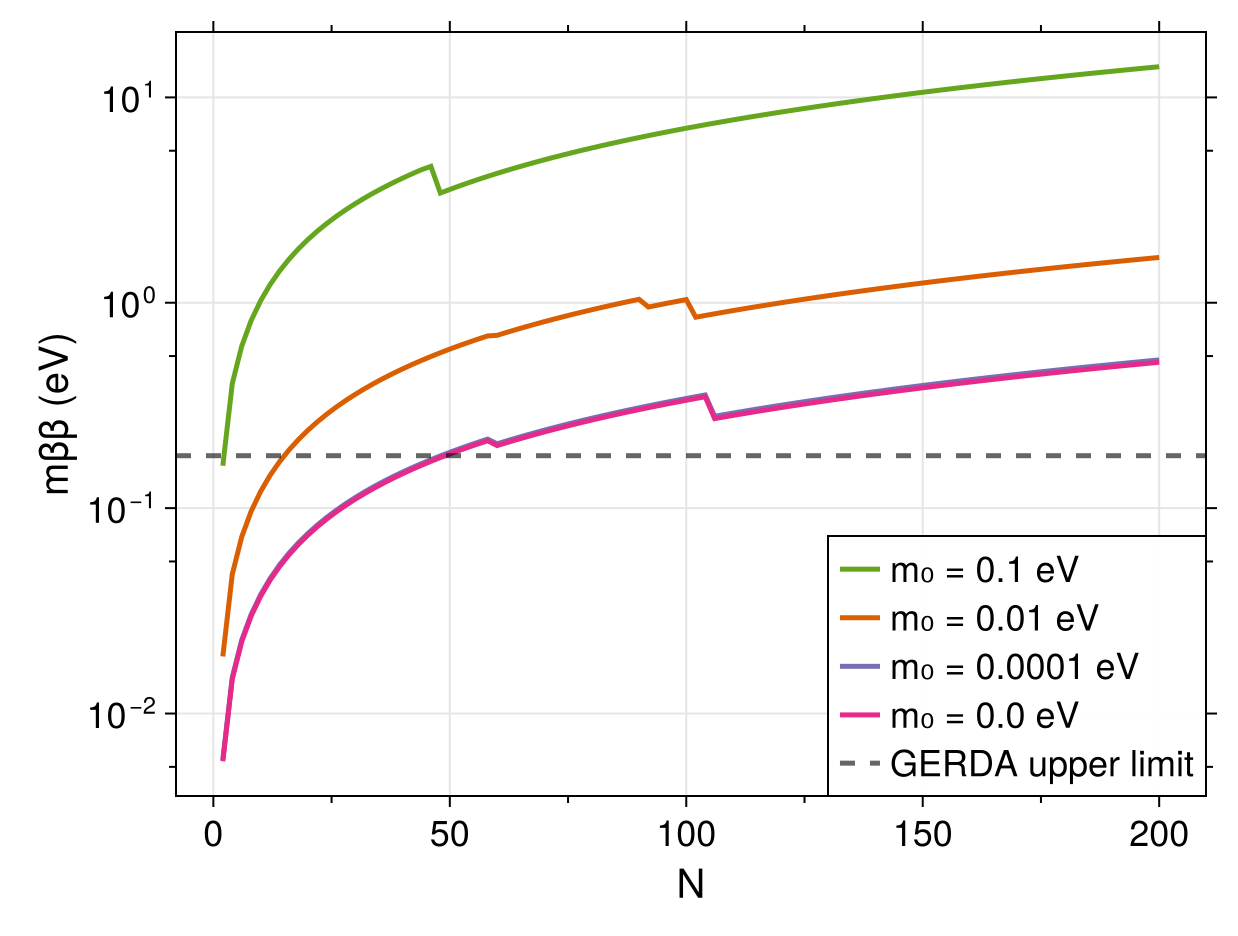

CairoMakie.Screen{IMAGE}


In [15]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

N_range = range(2, 200, length = 100)
m0_values = [0.1, 0.01,  0.0001, 0.0]

mass_by_m0 = Dict(m0 => Float64[] for m0 in m0_values)

f = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)

# ===================== COMPUTATION =====================

for n in N_range
    for m0 in m0_values
        p = merge(par, (m₀ = m0,), (r = 1,), (N = n,))
        push!(mass_by_m0[m0], f(p))
    end
end

# ===================== COLORS =====================

cs = ColorSchemes.Dark2_8

c_m01    = cs[5]  # m0 = 0.1
c_m001   = cs[2]  # m0 = 0.01
c_m0001  = cs[3]  # m0 = 0.001
c_m00001 = cs[4]  # m0 = 0.0001

colors = Dict(
    0.1    => c_m01,
    0.01   => c_m001,
    0.0001  => c_m0001,
    0.0    => c_m00001
)

# ===================== FIGURE - PRD STYLE =====================

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")
 # PRD single column width

ax = Axis(
    fig[1, 1],
   # title = nothing , #"Majorana effective mass mββ vs N — NNM IO - r = 1, η = 1 + 1/N",
    xlabel = "N",
    ylabel = "mββ (eV)",
    yscale = log10,
    xminorticksvisible = true,
    yminorticksvisible = true,
    #xminorgridvisible = true,
    #yminorgridvisible = true,
    titlesize = 18,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

# ===================== PLOTS =====================

for m0 in m0_values
    lines!(
        ax,
        N_range,
        mass_by_m0[m0];
        color = colors[m0],
        linewidth = 2.5,
        label = "m₀ = $(m0) eV"
    )
end

# ===================== GERDA LIMIT =====================

hlines!(
    ax,
    0.18;
    linestyle = :dash,
    linewidth = 2.5,
    color = (:black, 0.6),
    label = "GERDA upper limit"
)

# ===================== LEGEND WITH BOX =====================

# Create legend elements
legend_elements = []
legend_labels = []

for m0 in m0_values
    push!(legend_elements, LineElement(color = colors[m0], linewidth = 2.5, linestyle = :solid))
    push!(legend_labels, "m₀ = $(m0) eV")
end

push!(legend_elements, LineElement(color = (:black, 0.6), linewidth = 2.5, linestyle = :dash))
push!(legend_labels, "GERDA upper limit")

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "m₀ values",
    titlefont = :bold,
    titlesize = 20
)

# Display and save
display(fig)

#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/gerda_N_NNM_NO.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/gerda_N_NNM_NO.svg", fig)

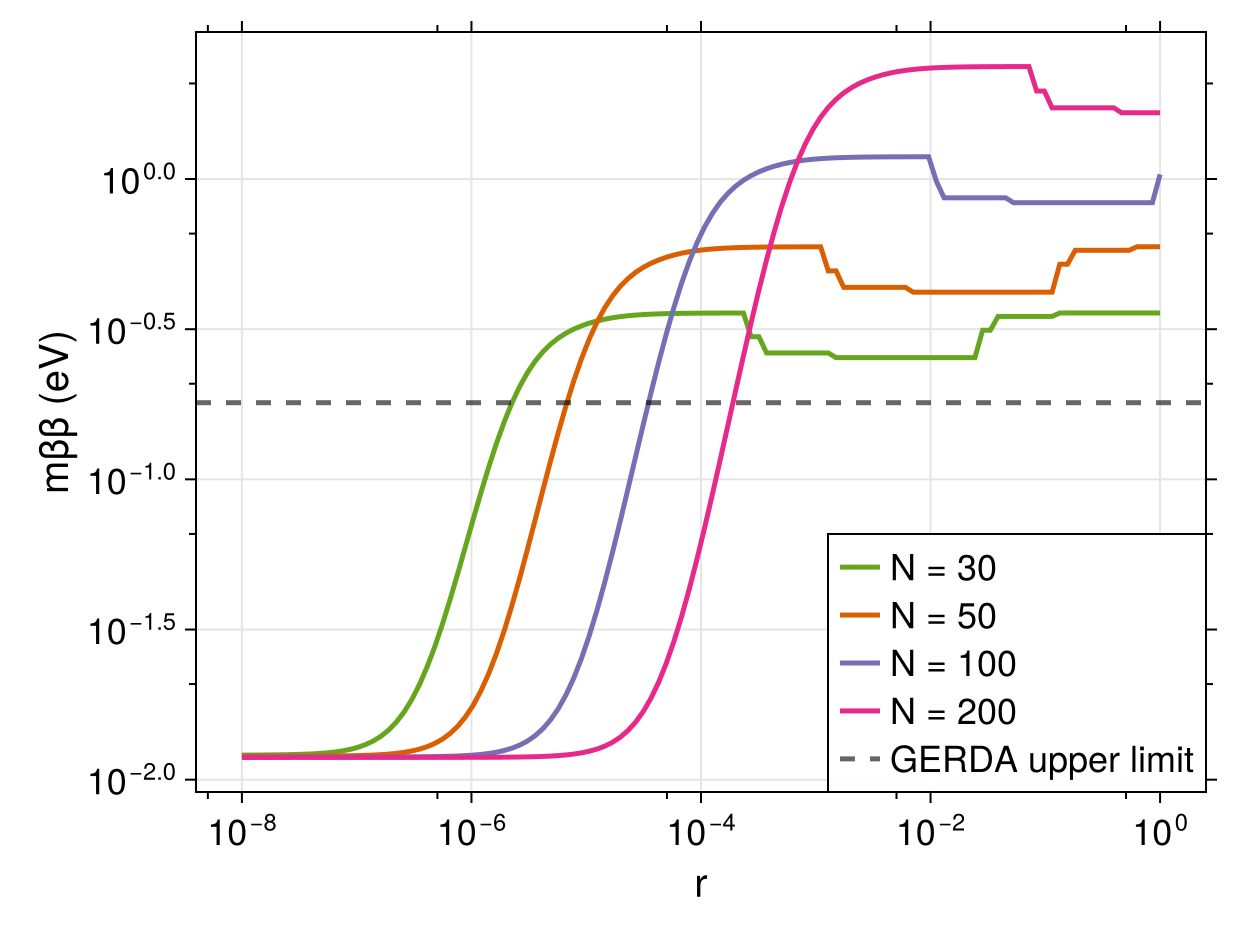

CairoMakie.Screen{IMAGE}


In [16]:
using CairoMakie
using ColorSchemes

# ===================== PARAMETERS =====================

r_range = logrange(1e-8, 1.0, 120)
N_values = [30, 50, 100, 200]
m0 = 0.01

mass_by_N = Dict(N => Float64[] for N in N_values)

f = Newtrinos.gerda.get_neutrinomass(osc_cfg.flavour)

# ===================== COMPUTATION =====================

for r in r_range
    for N in N_values
        p = merge(par, (m₀ = m0,), (r = r,), (N = N,))
        push!(mass_by_N[N], f(p))
    end
end

# ===================== COLORS (ORIGINAL ASSIGNMENTS PRESERVED) =====================

cs = ColorSchemes.Dark2_8

c_N30  = cs[5]   # N = 30
c_N50  = cs[2]   # N = 50
c_N100 = cs[3]   # N = 100
c_N200 = cs[4]   # N = 200

colors = Dict(
    30  => c_N30,
    50  => c_N50,
    100 => c_N100,
    200 => c_N200
)

# ===================== FIGURE - PRD STYLE =====================

fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")  # PRD single column width

ax = Axis(
    fig[1, 1],
    #title = "Majorana effective mass mββ vs r — NNM IO - m₀ = $m0 eV, η = 1 + 1/N",
    xlabel = "r",
    ylabel = "mββ (eV)",
    xscale = log10,
    yscale = log10,
    xminorticksvisible = true,
    #xminorgridvisible = true,
    yminorticksvisible = true,
    #yminorgridvisible = true,
    titlesize = 18,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = true,
    ygridvisible = true,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true
)

# ===================== PLOTS =====================

for N in N_values
    lines!(
        ax,
        r_range,
        mass_by_N[N];
        color = colors[N],
        linewidth = 2.5,
        label = "N = $N"
    )
end

# ===================== GERDA LIMIT =====================

hlines!(
    ax,
    0.18;
    linestyle = :dash,
    linewidth = 2.5,
    color = (:black, 0.6),
    label = "GERDA upper limit"
)

# ===================== LEGEND WITH BOX =====================

# Create legend elements
legend_elements = []
legend_labels = []

for N in N_values
    push!(legend_elements, LineElement(color = colors[N], linewidth = 2.5, linestyle = :solid))
    push!(legend_labels, "N = $N")
end

push!(legend_elements, LineElement(color = (:black, 0.6), linewidth = 2.5, linestyle = :dash))
push!(legend_labels, "GERDA upper limit")

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :right,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "N values",
    titlefont = :bold,
    titlesize = 20
)

# Display and save
display(fig)

#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/gerda_r_NNM_NO.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/gerda_r_NNM_NO.svg", fig)

Oscillations plots

In [17]:
using LinearAlgebra
using Distributions
using FileIO
import JLD2
using DataFrames
using CairoMakie

#NNATURALNESS 

using Revise
using Newtrinos

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

p = Newtrinos.get_params(experiments)

[ Info: Loading dayabay data


(N = 10.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [18]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using Revise
using Newtrinos
using CairoMakie
using ColorSchemes
using DataFrames

# ------------------------------------------------------------
# STANDARD MODEL
# ------------------------------------------------------------

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS
# ------------------------------------------------------------

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc)

experiments = (
    dayabay = Newtrinos.dayabay.configure(physics),
)

p = Newtrinos.get_params(experiments)

# Define ftype - this is likely a type alias in Newtrinos
# Common possibilities:
ftype = Float64  # or Newtrinos.ParameterType, Float32, etc.

# Alternative if Newtrinos has its own type:
# ftype = Newtrinos.osc.RealType  # or whatever is appropriate

# Or simply use Float64 directly:
p_5  = merge(p, (N=5.0,  r=1.0))
p_10 = merge(p, (N=10.0, r=1.0))
p_20 = merge(p, (N=20.0, r=1.0))
p_50 = merge(p, (N=50.0, r=1.0))


[ Info: Loading dayabay data
[ Info: Loading dayabay data


(N = 50.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.1, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

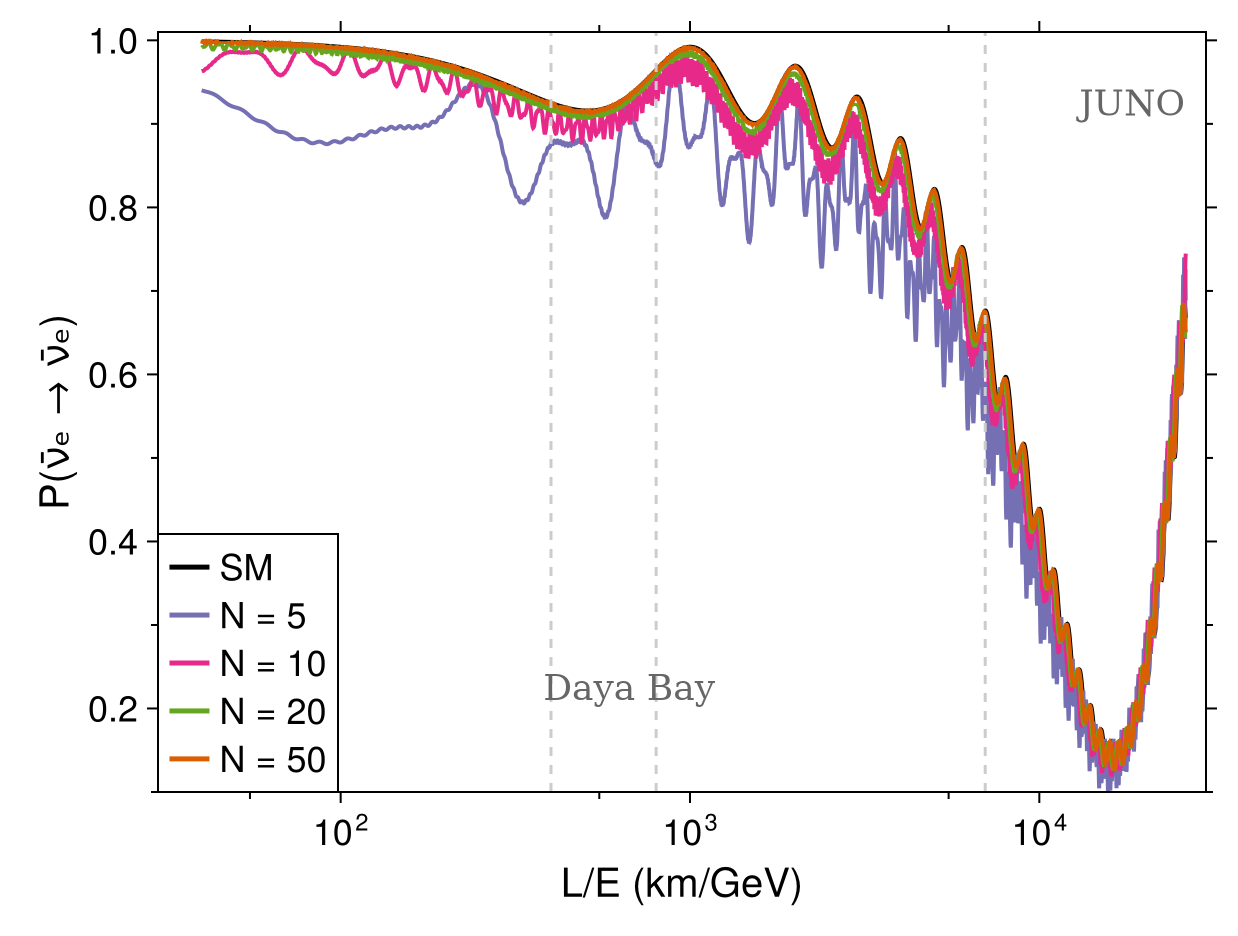

CairoMakie.Screen{IMAGE}


In [20]:

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS
# ------------------------------------------------------------

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)
# ------------------------------------------------------------
# L/E RANGE COVERING DAYABAY + JUNO
# ------------------------------------------------------------

LE_min = 1.6 / 0.04      # 40 km/GeV
LE_max = 52.5 / 0.002    # 26250 km/GeV

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

# ------------------------------------------------------------
# Choose a reference baseline
#
# Since vacuum oscillations depend on L/E,
# any fixed baseline works.
# ------------------------------------------------------------

L_ref = 52.5  # km (JUNO)

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_5  = osc_prob(E_vals, L_vec, p_5; anti=true)
probab_10 = osc_prob(E_vals, L_vec, p_10; anti=true)
probab_20 = osc_prob(E_vals, L_vec, p_20; anti=true)
probab_50 = osc_prob(E_vals, L_vec, p_50; anti=true)

# ------------------------------------------------------------
# PLOT - PRD PAPER READY STYLE (BIGGER VERSION)
# ------------------------------------------------------------

# Color palette (Dark2_8 categorical) - ORIGINAL ASSIGNMENTS PRESERVED
palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1]  # N=50
c_2 = palette[2]  # SM (black in original, but we'll use palette[2] for consistency)
c_3 = palette[3]  # N=5
c_4 = palette[4]  # N=10
c_5 = palette[5]  # N=20

# PRD single column width (8.6 cm) with appropriate height
fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")

ax = Axis(
    fig[1,1],
    xlabel = "L/E (km/GeV)",  # No LaTeX
    ylabel = "P(ν̄ₑ → ν̄ₑ)",  # Simple text, no LaTeX
    xlabelsize = 20,
    ylabelsize = 20,
    titlesize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = false,
     ygridvisible = false,
    #xgridcolor = :gray90,
    #ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true,
    xminorticksvisible = true,
    yminorticksvisible = true,
    #xminorgridvisible = true,
    #yminorgridvisible = true,
    xscale = log10
)

# Line plots with original color assignments and 2.5 pt linewidth
lines!(ax, LE_range, probab_SM[:,1,1,1],
    label = "SM", linewidth = 2, color = :black)  # SM stays black

lines!(ax, LE_range, probab_5[:,1,1,1],
    label = "N = 5", linewidth = 2, color = c_3)

lines!(ax, LE_range, probab_10[:,1,1,1],
    label = "N = 10", linewidth = 2, color = c_4)

lines!(ax, LE_range, probab_20[:,1,1,1],
    label = "N = 20", linewidth = 2, color = c_5)

lines!(ax, LE_range, probab_50[:,1,1,1],
    label = "N = 50", linewidth = 2, color = c_2)


# Axis limits
ylims!(ax, 0.10, 1.01)
xlims!(ax, 30, 30000)

# Create legend with box matching PRD style (BIGGER VERSION)
legend_elements = [
    LineElement(color=:black, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_3, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_4, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_5, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_2, linewidth=2.5, linestyle=:solid)
]

legend_labels = ["SM", "N = 5", "N = 10", "N = 20", "N = 50"]

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :left,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Oscillation Probabilities",
    titlefont = :bold,
    titlesize = 20
)

# Mark experiment regions (subtle gray lines)
vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.0075], linestyle=:dash, color=:gray80, linewidth=1.5)

# Text labels for experiment regions (BIGGER fonts)
text!(ax, 380, 0.2, text = "Daya Bay", fontsize = 18, color = :gray40)
text!(ax, 13000, 0.9, text = "JUNO", fontsize = 18, color = :gray40)

# Display and save
display(fig)

# Save options (update paths as needed)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/oscillation_probability_LE_dayabay_juno_paper_N.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/oscillation_probability_LE_dayabay_juno_paper_N.svg", fig)

[ Info: Loading dayabay data
[ Info: Loading dayabay data


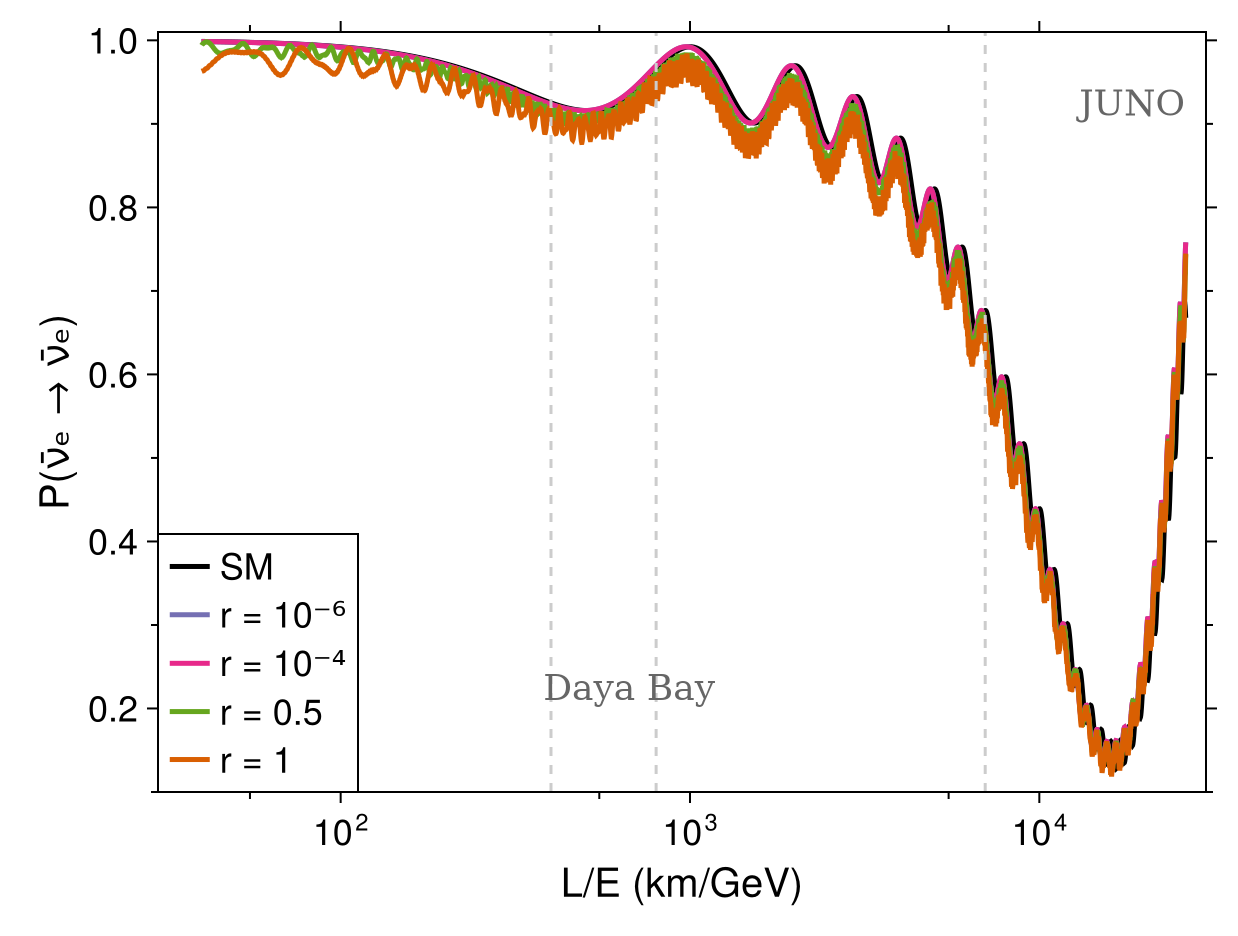

CairoMakie.Screen{IMAGE}


In [21]:
using Revise
using Newtrinos
using CairoMakie
using ColorSchemes

# ------------------------------------------------------------
# STANDARD MODEL
# ------------------------------------------------------------

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers)

experiments_SM = (
    dayabay = Newtrinos.dayabay.configure(physics_SM),
)

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)

# ------------------------------------------------------------
# N-NATURALNESS - VARYING r
# ------------------------------------------------------------

# Define oscillation configuration for NND model
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
)

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc)

experiments = (
    dayabay = Newtrinos.dayabay.configure(physics),
)

osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p = Newtrinos.get_params(experiments)

# Get the parameter type from the existing parameters
ftype = typeof(p.N)  # or use Float64 directly if this doesn't work

# Fixed N = 10 for all except r=0.5 (which uses N=11 to match your original)
p_r0   = merge(p, (N=ftype(10), r=ftype(1e-6)))
p_r025 = merge(p, (N=ftype(10), r=ftype(1e-4)))
p_r05  = merge(p, (N=ftype(11), r=ftype(0.5)))  # N=11 as in your original
p_r1   = merge(p, (N=ftype(10), r=ftype(1)))

# ------------------------------------------------------------
# L/E RANGE COVERING DAYABAY + JUNO
# ------------------------------------------------------------

LE_min = 1.6 / 0.04      # 40 km/GeV
LE_max = 52.5 / 0.002    # 26250 km/GeV

LE_range = exp10.(range(log10(LE_min),
                        log10(LE_max),
                        length=3000))

# ------------------------------------------------------------
# Choose a reference baseline
#
# Since vacuum oscillations depend on L/E,
# any fixed baseline works.
# ------------------------------------------------------------

L_ref = 52.5  # km (JUNO)

E_vals = collect(L_ref ./ LE_range)

L_vec = [L_ref]

# ------------------------------------------------------------
# PROBABILITIES
# ------------------------------------------------------------

probab_SM = osc_prob_SM(E_vals, L_vec, p_SM; anti=true)

probab_r0   = osc_prob(E_vals, L_vec, p_r0; anti=true)
probab_r025 = osc_prob(E_vals, L_vec, p_r025; anti=true)
probab_r05  = osc_prob(E_vals, L_vec, p_r05; anti=true)
probab_r1   = osc_prob(E_vals, L_vec, p_r1; anti=true)

# ------------------------------------------------------------
# PLOT - PRD PAPER READY STYLE (BIGGER VERSION) - VARYING r
# ------------------------------------------------------------

# Color palette (Dark2_8 categorical) - ORIGINAL ASSIGNMENTS PRESERVED
palette = cgrad(:Dark2_8, categorical=true)
c_1 = palette[1]  # r=1 (will use c_2 for SM)
c_2 = palette[2]  # SM (black)
c_3 = palette[3]  # r=1e-6
c_4 = palette[4]  # r=1e-4
c_5 = palette[5]  # r=0.5

# PRD single column width (8.6 cm) with appropriate height
fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif") 

ax = Axis(
    fig[1,1],
    xlabel = "L/E (km/GeV)",  # No LaTeX
    ylabel = "P(ν̄ₑ → ν̄ₑ)",  # Simple text, no LaTeX
    xlabelsize = 20,
    ylabelsize = 20,
    titlesize = 20,
    xticklabelsize = 18,
    yticklabelsize = 18,
    xgridvisible = false,
    ygridvisible = false,
    xgridcolor = :gray90,
    ygridcolor = :gray90,
    xticksmirrored = true,
    yticksmirrored = true,
    xminorticksvisible = true,
    yminorticksvisible = true,
    xscale = log10
)

# Line plots with original color assignments and 2.5 pt linewidth
lines!(ax, LE_range, probab_SM[:,1,1,1],
    label = "SM", linewidth = 2.5, color = :black)  # SM stays black

lines!(ax, LE_range, probab_r0[:,1,1,1],
    label = "r = 10⁻⁶", linewidth = 2.5, color = c_3)

lines!(ax, LE_range, probab_r025[:,1,1,1],
    label = "r = 10⁻⁴", linewidth = 2.5, color = c_4)

lines!(ax, LE_range, probab_r05[:,1,1,1],
    label = "r = 0.5", linewidth = 2.5, color = c_5)

lines!(ax, LE_range, probab_r1[:,1,1,1],
    label = "r = 1", linewidth = 2.5, color = c_2)

# Axis limits
ylims!(ax, 0.10, 1.01)
xlims!(ax, 30, 30000)

# Create legend with box matching PRD style (BIGGER VERSION)
legend_elements = [
    LineElement(color=:black, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_3, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_4, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_5, linewidth=2.5, linestyle=:solid),
    LineElement(color=c_2, linewidth=2.5, linestyle=:solid)
]

legend_labels = ["SM", "r = 10⁻⁶", "r = 10⁻⁴", "r = 0.5", "r = 1"]

Legend(
    fig[1,1],
    legend_elements,
    legend_labels;
    tellwidth = false,
    tellheight = false,
    halign = :left,
    valign = :bottom,
    labelsize = 18,
    framevisible = true,
    backgroundcolor = (:white, 0.95),
    strokecolor = :black,
    strokewidth = 0.5,
    title = "Oscillation Probabilities",
    titlefont = :bold,
    titlesize = 20
)

# Mark experiment regions (subtle gray lines)
vlines!(ax, [1.6/0.002], linestyle=:dash, color=:gray80, linewidth=1.5)   
vlines!(ax, [1.6/0.004], linestyle=:dash, color=:gray80, linewidth=1.5)
vlines!(ax, [52.5/0.001], linestyle=:dash, color=:gray80, linewidth=1.5) 
vlines!(ax, [52.5/0.0075], linestyle=:dash, color=:gray80, linewidth=1.5)

# Text labels for experiment regions (scaled for PRD)
text!(ax, 380, 0.2, text = "Daya Bay", fontsize = 18, color = :gray40)
text!(ax, 13000, 0.9, text = "JUNO", fontsize = 18, color = :gray40)

# Display and save
display(fig)

# Save options (update paths as needed)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/oscillation_probability_LE_dayabay_juno_paper_r.png", fig)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/oscillation_probability_LE_dayabay_juno_paper_r.svg", fig)

Daya bay data

In [22]:
using CairoMakie
using ColorSchemes

    function plot_r(params, data = assets.observed)
        assets=experiments.dayabay.assets
        r_values = [10^-6, 10^-4, 0.5, 1]
        r_labels = ["10⁻⁶", "10⁻⁴", "0.5", "1"] 

        # Color palette matching oscillation plots (Dark2_8 categorical)
        palette = cgrad(:Dark2_8, categorical=true)
        
        # Color associations consistent with oscillation plots:
        # SM/black is separate, here we use colors for r values
        c_1 = palette[1]  # r = 1e-6
        c_2 = palette[2]  # r = 1e-4
        c_3 = palette[3]  # r = 0.5
        c_4 = palette[4] 
        c_5 = palette[5] # r = 1

        colors = [c_3, c_4, c_5, c_2]

        # --- compute means and variances ---
        all_means = []
        all_variances = []

        forward = Newtrinos.dayabay.get_forward_model(physics, assets)

        for r in r_values
            p_r = merge(params, (r = Float64(r),))
            m = mean(forward(p_r))
            v = var(forward(p_r))

            push!(all_means, m)
            push!(all_variances, v)
        end

        # --- figure layout with PRD styling (BIGGER VERSION) ---
       fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")  # PRD single column width

        ax = Axis(fig[1,1], 
            ylabel = "Counts", 
            xlabelsize = 20,
            ylabelsize = 20,
            titlesize = 20,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xgridvisible = true,
            ygridvisible = true,
            xgridcolor = :gray90,
            ygridcolor = :gray90,
            xticksmirrored = true,
            yticksmirrored = true,
            xminorticksvisible = true,
            yminorticksvisible = true,
            #xminorgridvisible = true,
            #yminorgridvisible = true
        )

        ax2 = Axis(
            fig[2,1],
            xlabel = "E (MeV)",
            ylabel = "Data / Predictions",
            xlabelsize = 20,
            ylabelsize = 20,
            titlesize = 20,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xgridvisible = true,
            ygridvisible = true,
            xgridcolor = :gray90,
            ygridcolor = :gray90,
            xticksmirrored = true,
            yticksmirrored = true,
            xminorticksvisible = true,
            yminorticksvisible = true,
            #xminorgridvisible = true,
            #yminorgridvisible = true
        )
        
        # Make second subplot larger
        rowsize!(fig.layout, 1, Relative(0.45))  # 45% for top
        rowsize!(fig.layout, 2, Relative(0.55))  # 55% for bottom
        rowgap!(fig.layout, 5)

        # --- expected spectra ---
        for (i, r) in enumerate(r_values)

            m = all_means[i]
            v = all_variances[i]
            col = colors[i]

            stephist!(
                ax,
                assets.energy,
                weights = m,
                bins = assets.energy_bins,
                color = col,
                label = "Expected r = $(r_labels[i])",
                linewidth = 2
            )

            barplot!(
                ax,
                assets.energy,
                m .+ sqrt.(v),
                width = diff(assets.energy_bins),
                gap = 0,
                fillto = m .- sqrt.(v),
                alpha = 0.25,
                color = col
            )

            # --- ratio ---
            stephist!(
                ax2,
                assets.energy,
                weights = data ./ m,
                bins = assets.energy_bins,
                color = col,
                label = "Ratio r = $(r_labels[i])",
                linewidth = 2
            )
        end
        
        # Add gray error band only for the last prediction (r=1)
        last_idx = length(r_values)
        m_last = all_means[last_idx]
        v_last = all_variances[last_idx]
        
        barplot!(
            ax2,
            assets.energy,
            1 .+ sqrt.(v_last) ./ m_last,
            width = diff(assets.energy_bins),
            gap = 0,
            fillto = 1 .- sqrt.(v_last) ./ m_last,
            alpha = 0.25,
            color = :gray
        )
             
        plot!(
            ax,
            assets.energy,
            data,
            color = :black,
            label = "Observed",
    
        )
        hlines!(ax2, 1, color=:black, linestyle=:dash, linewidth=2.5)

        # --- axes cleanup ---
        ax.xticksvisible = false
        ax.xticklabelsvisible = false

        xlims!(ax, minimum(assets.energy_bins), maximum(assets.energy_bins))
        xlims!(ax2, minimum(assets.energy_bins), maximum(assets.energy_bins))

        ylims!(ax, 0, 60000)
        ylims!(ax2, 0.9, 1.1)

        # Create legend with box matching PRD style (BIGGER VERSION)
        legend_elements = []
        for (i, r) in enumerate(r_values)
            push!(legend_elements, LineElement(color=colors[i], linewidth=2.5, linestyle=:solid))
        end
        push!(legend_elements, MarkerElement(color=:black, marker=:circle, markersize=10))
        
        legend_labels = ["r = $(r_labels[i])" for i in 1:length(r_values)]
        push!(legend_labels, "Observed")
        
        
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth = false,
            tellheight = false,
            halign = :right,
            valign = :top,
            labelsize = 20,
            framevisible = true,
            backgroundcolor = (:white, 0.95),
            strokecolor = :black,
            strokewidth = 0.5,
            title = "N values",
            titlefont = :bold,
            titlesize = 20
        )
        return fig
       # save("/home/sofialon/Newtrinos.jl/scan_plot_paper/dayabay_data_NND_NO_r_new.png", fig)
       # save("/home/sofialon/Newtrinos.jl/scan_plot_paper/dayabay_data_NND_NO_r_new.svg", fig)
    end



    function plot_N(params, data = assets.observed)
        assets=experiments.dayabay.assets

        N_values = [5, 10, 20, 50]

        # Color palette matching oscillation plots (Dark2_8 categorical)
        palette = cgrad(:Dark2_8, categorical=true)
        
        # Color associations consistent with oscillation plots:
        # N=50 -> palette[1], N=5 -> palette[3], N=10 -> palette[4], N=20 -> palette[5]
        # But here we have 4 values, so we use palette[1-4]
        c_1 = palette[1]  # N=50
        c_2 = palette[2]  # N=5 (or adjust based on preference)
        c_3 = palette[3]  # N=10
        c_4 = palette[4]
        c_5 = palette[5]  # N=20

        # Reorder to match typical presentation (small to large N)
        # N=5: c_2, N=10: c_3, N=20: c_4, N=50: c_1
        colors = Dict(
            5 => c_3,
            10 => c_4,
            20 => c_5,
            50 => c_2
        )

        # --- compute means and variances ---
        all_means = Dict()
        all_variances = Dict()

        forward =Newtrinos.dayabay.get_forward_model(physics, assets)
       
        for N in N_values
            p_N = merge(params, (N = Float64(N),))
            m = mean(forward(p_N))
            v = var(forward(p_N))
            all_means[N] = m
            all_variances[N] = v
        end

        # --- figure layout with PRD styling (BIGGER VERSION) ---
        fig = Figure(size=(8.6*72, 6.5*72), font="CMU Serif")  # PRD single column width

        ax = Axis(fig[1,1], 
            ylabel = "Counts", 
            xlabelsize = 20,
            ylabelsize = 20,
            titlesize = 20,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xgridvisible = true,
            ygridvisible = true,
            xgridcolor = :gray90,
            ygridcolor = :gray90,
            xticksmirrored = true,
            yticksmirrored = true,
            xminorticksvisible = true,
            yminorticksvisible = true,
            #xminorgridvisible = true,
            #yminorgridvisible = true
        )

        ax2 = Axis(
            fig[2,1],
            xlabel = "E (MeV)",
            ylabel = "Data / Predictions",
            xlabelsize = 20,
            ylabelsize = 20,
            titlesize = 20,
            xticklabelsize = 18,
            yticklabelsize = 18,
            xgridvisible = true,
            ygridvisible = true,
            xgridcolor = :gray90,
            ygridcolor = :gray90,
            xticksmirrored = true,
            yticksmirrored = true,
            xminorticksvisible = true,
            yminorticksvisible = true,
            #xminorgridvisible = true,
            #yminorgridvisible = true
        )
        
        # Make second subplot larger
        rowsize!(fig.layout, 1, Relative(0.45))  # 45% for top
        rowsize!(fig.layout, 2, Relative(0.55))  # 55% for bottom
        rowgap!(fig.layout, 5)

        # --- expected spectra (plot in order of increasing N) ---
        for N in sort(N_values)
            m = all_means[N]
            v = all_variances[N]
            col = colors[N]

            stephist!(
                ax,
                assets.energy,
                weights = m,
                bins = assets.energy_bins,
                color = col,
                label = "Expected N = $(N)",
                linewidth = 2
            )

            barplot!(
                ax,
                assets.energy,
                m .+ sqrt.(v),
                width = diff(assets.energy_bins),
                gap = 0,
                fillto = m .- sqrt.(v),
                alpha = 0.25,
                color = col
            )

            # --- ratio ---
            stephist!(
                ax2,
                assets.energy,
                weights = data ./ m,
                bins = assets.energy_bins,
                color = col,
                linewidth = 2
            )
        end
        
        # Add gray error band only for the last prediction (N=50)
        last_N = sort(N_values)[end]
        m_last = all_means[last_N]
        v_last = all_variances[last_N]
        
        barplot!(
            ax2,
            assets.energy,
            1 .+ sqrt.(v_last) ./ m_last,
            width = diff(assets.energy_bins),
            gap = 0,
            fillto = 1 .- sqrt.(v_last) ./ m_last,
            alpha = 0.25,
            color = :gray
        )
             
        plot!(
            ax,
            assets.energy,
            data,
            color = :black,
            label = "Observed"      
              )


        hlines!(ax2, 1, color=:black, linestyle=:dash, linewidth=2)

        # --- axes cleanup ---
        ax.xticksvisible = false
        ax.xticklabelsvisible = false

        xlims!(ax, minimum(assets.energy_bins), maximum(assets.energy_bins))
        xlims!(ax2, minimum(assets.energy_bins), maximum(assets.energy_bins))

        ylims!(ax, 0, 60000)
        ylims!(ax2, 0.9, 1.2)

        # Create legend with box matching PRD style (BIGGER VERSION)
        legend_elements = []
        for N in sort(N_values)
            push!(legend_elements, LineElement(color=colors[N], linewidth=2.5, linestyle=:solid))
        end
        push!(legend_elements, MarkerElement(color=:black, marker=:circle, markersize=10))
        
        legend_labels = ["N = $(N)" for N in sort(N_values)]
        push!(legend_labels, "Observed")
        
        Legend(
            fig[1,1],
            legend_elements,
            legend_labels;
            tellwidth = false,
            tellheight = false,
            halign = :right,
            valign = :top,
            labelsize = 18,
            framevisible = true,
            backgroundcolor = (:white, 0.95),
            strokecolor = :black,
            strokewidth = 0.5,
            title = "N values",
            titlefont = :bold,
            titlesize = 20
        )
          return fig
     #   save("/home/sofialon/Newtrinos.jl/scan_plot_paper/dayabay_data_NND_NO_N_new.png", fig)
      #  save("/home/sofialon/Newtrinos.jl/scan_plot_paper/dayabay_data_NND_NO_N_new.svg", fig)
    end



plot_N (generic function with 2 methods)

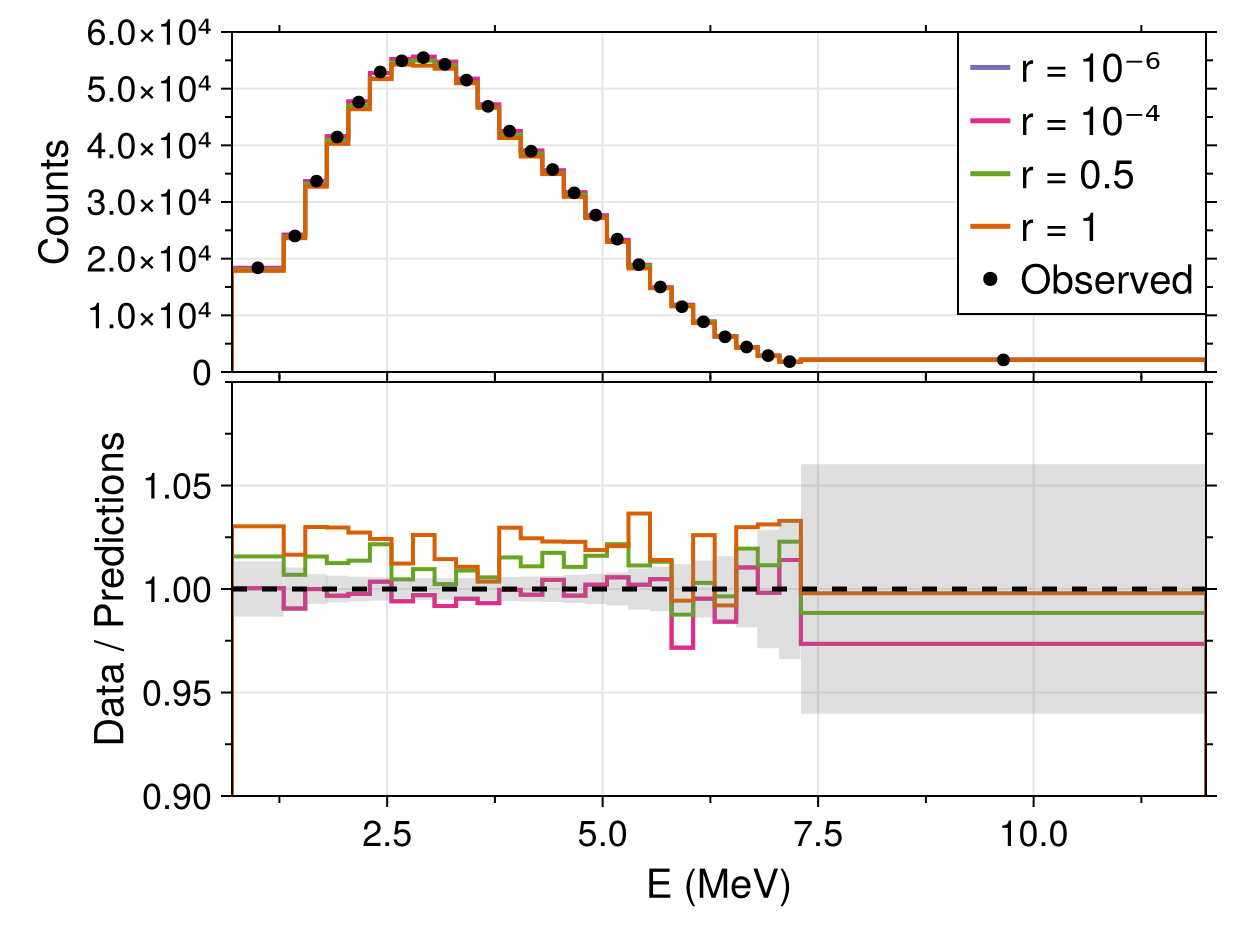

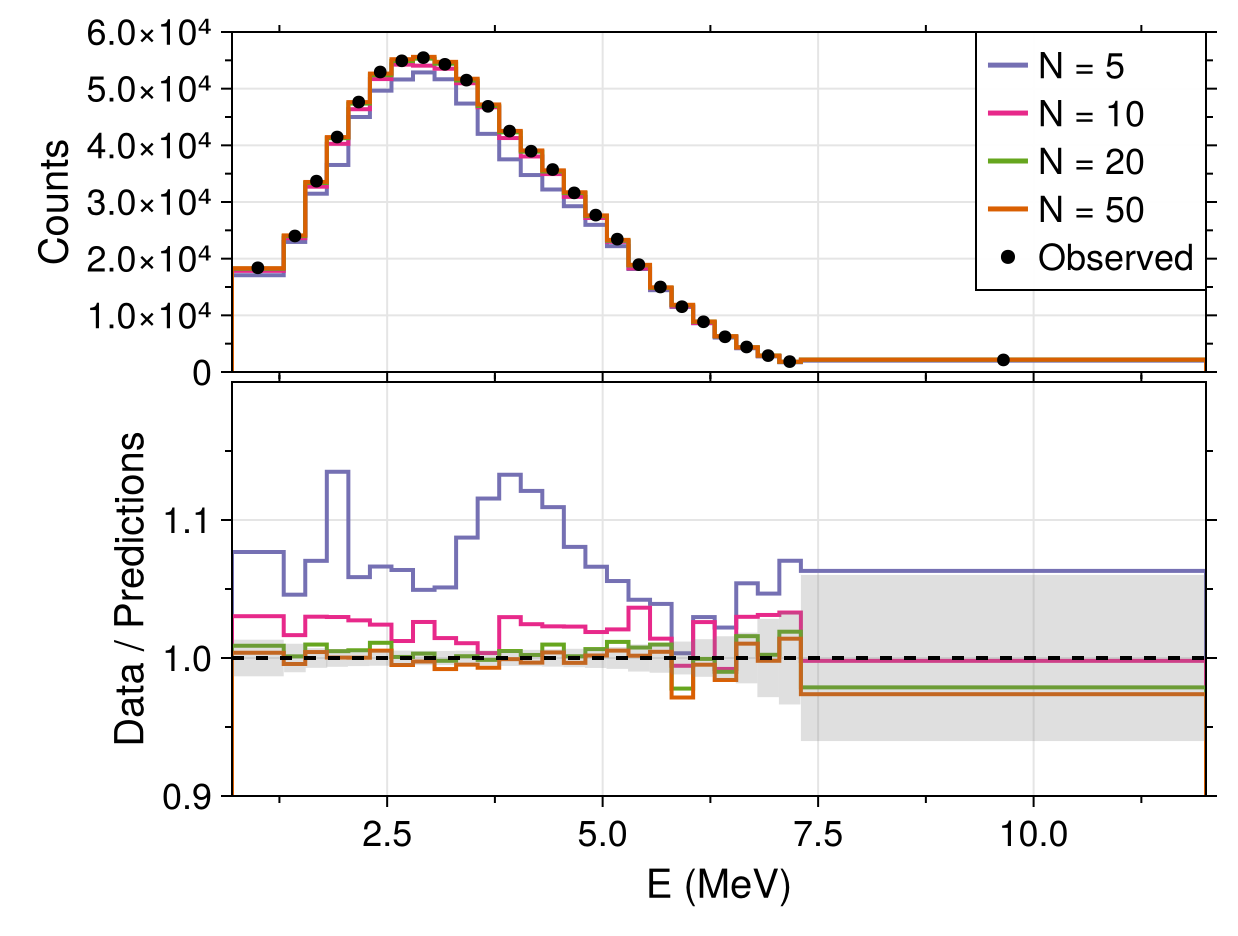

CairoMakie.Screen{IMAGE}


In [23]:
fig_r= plot_r(p, experiments.dayabay.assets.observed)
display(fig_r)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/dayabay_data_NND_NO_r_new.png", fig_r)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/dayabay_data_NND_NO_r_new.svg", fig_r)
fig_N = plot_N(p, experiments.dayabay.assets.observed)
display(fig_N)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/dayabay_data_NND_NO_N_new.png", fig_N)
#save("/home/sofialon/Newtrinos.jl/scan_plot_paper/dayabay_data_NND_NO_N_new.svg", fig_N)